# Analiza Ról Użytkowników w Debatach Dezinformacyjnych
## Projekt: Kto napędza dyskusję?

**Cel:** Profilowanie ról użytkowników i pomiar "temperatury" dyskusji w subredditach

---

### Metodologia:
1. **Data Engineering** - Rekonstrukcja sieci interakcji
2. **Feature Engineering** - Wyliczenie cech użytkowników
3. **Temperature Index** - Metryka intensywności sporu
4. **Clustering** - Identyfikacja ról (K-Means)
5. **Wizualizacja** - Graf sieciowy z kolorami klastrów

## 📚 ETAP 1: Import Bibliotek i Wczytanie Danych

Instalujemy i importujemy wszystkie potrzebne biblioteki do analizy sieciowej, NLP i ML.

In [1]:
# Instalacja wymaganych pakietów (uruchom jednokrotnie)
import sys
%pip install -q pandas numpy networkx scikit-learn matplotlib seaborn nltk textblob tqdm pyvis

# Pobieranie leksykonów VADER dla analizy sentymentu
import nltk
nltk.download('vader_lexicon', quiet=True)
print("✓ Wszystkie pakiety zainstalowane (w tym tqdm i pyvis)")


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
✓ Wszystkie pakiety zainstalowane (w tym tqdm i pyvis)


In [2]:
# Import standardowych bibliotek
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# NLP - Analiza sentymentu
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Ustawienia wizualizacji
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("✓ Biblioteki zaimportowane")

✓ Biblioteki zaimportowane


In [148]:
# Wczytanie danych z CSV
# UWAGA: Zmień ścieżkę na właściwą dla Twojego pliku
flatearth_data_path = './flatearth.csv'
aliens_data_path = './aliens.csv'
chemitrails_data_path = './chemtrails.csv'
news_data_path = './news.csv'

flatearth_df = pd.read_csv(flatearth_data_path)
aliens_df = pd.read_csv(aliens_data_path)
chemitrails_df = pd.read_csv(chemitrails_data_path)
news_df = pd.read_csv(news_data_path)

dataframes = {
    'flatearth': flatearth_df,
    'aliens': aliens_df,
    'chemtrails': chemitrails_df,
    'news': news_df
}

# Konwersja timestamp na datetime
for df in dataframes.values():
    df['timestamp'] = pd.to_datetime(df['timestamp'])

# Pierwsze spojrzenie na dane
for name, df in dataframes.items():
    print(f'\n\n{name}')
    print(f"📊 Załadowano {len(df)} wierszy")
    print(f"📅 Zakres czasowy: {df['timestamp'].min()} → {df['timestamp'].max()}")
    print(f"👥 Liczba unikalnych autorów: {df['author'].nunique()}")
    print(f"💬 Typy aktywności: {df['activity_type'].value_counts().to_dict()}")

    # Podgląd struktury
    df.head()



flatearth
📊 Załadowano 17606 wierszy
📅 Zakres czasowy: 2015-09-25 15:42:23+00:00 → 2026-01-13 06:18:55+00:00
👥 Liczba unikalnych autorów: 4668
💬 Typy aktywności: {'comment': 17170, 'post': 436}


aliens
📊 Załadowano 34030 wierszy
📅 Zakres czasowy: 2014-01-26 21:00:24+00:00 → 2026-01-08 16:03:03+00:00
👥 Liczba unikalnych autorów: 14045
💬 Typy aktywności: {'comment': 33649, 'post': 381}


chemtrails
📊 Załadowano 39657 wierszy
📅 Zakres czasowy: 2013-02-21 16:37:52+00:00 → 2026-01-20 19:21:35+00:00
👥 Liczba unikalnych autorów: 8415
💬 Typy aktywności: {'comment': 39222, 'post': 435}


news
📊 Załadowano 68703 wierszy
📅 Zakres czasowy: 2009-06-25 21:47:51+00:00 → 2026-01-21 07:19:31+00:00
👥 Liczba unikalnych autorów: 30255
💬 Typy aktywności: {'comment': 68241, 'post': 462}


### Add post_id to each row

In [149]:
for name, df in dataframes.items():
    df["post_id"] = np.where(
        df["activity_type"] == "post",
        df["activity_id"],
        np.nan
    )

    id_to_post_id = dict(zip(df["activity_id"], df["post_id"]))
    changed = True

    while changed:
        changed = False
        
        for idx, row in df[df["post_id"].isna()].iterrows():
            parent = row["parent_id"]
            
            if parent in id_to_post_id and pd.notna(id_to_post_id[parent]):
                df.at[idx, "post_id"] = id_to_post_id[parent]
                id_to_post_id[row["activity_id"]] = id_to_post_id[parent]
                changed = True


### Get comment threads

In [150]:
comments_df_dict = {
    name: df[df["activity_type"] == "comment"].copy()
    for name, df in dataframes.items()
}

#### chain of parent comments

In [151]:
for name, df in dataframes.items():
    comments_df = comments_df_dict[name]
    parent_lookup = dict(zip(df["activity_id"], df["parent_id"]))
    timestamp_lookup = dict(zip(df["activity_id"], df["timestamp"]))
    type_lookup = dict(zip(df["activity_id"], df["activity_type"]))

    def get_parent_comment_chain(comment_id):
        chain = []
        current_parent = parent_lookup.get(comment_id)

        while current_parent and type_lookup.get(current_parent) == "comment":
            chain.append(current_parent)
            current_parent = parent_lookup.get(current_parent)

        return chain[::-1]
    
    comments_df["parent_comments_ids"] = comments_df["activity_id"].apply(
        get_parent_comment_chain
    )


#### parent comment timestamp

In [152]:
for name, df in dataframes.items():
    comments_df = comments_df_dict[name]
    parent_lookup = dict(zip(df["activity_id"], df["parent_id"]))
    timestamp_lookup = dict(zip(df["activity_id"], df["timestamp"]))
    type_lookup = dict(zip(df["activity_id"], df["activity_type"]))

    def get_direct_parent_timestamp(comment_id):
        parent = parent_lookup.get(comment_id)
        if type_lookup.get(parent) == "comment":
            return timestamp_lookup.get(parent)
        return pd.NaT

    comments_df["parent_comment_timestamp"] = comments_df["activity_id"].apply(
        get_direct_parent_timestamp
    )

#### number of replies

In [153]:
for name, df in dataframes.items():
    comments_df = comments_df_dict[name]
    comments = comments_df.copy()

    reply_counts = (
        comments
        .groupby('parent_id')
        .size()
        .rename('num_replies')
    )

    comments = comments.merge(
        reply_counts,
        left_on='activity_id',
        right_index=True,
        how='left'
    )

    comments['num_replies'] = comments['num_replies'].fillna(0)
    comments_df_dict[name] = comments

#### reply delay

In [154]:
for name, df in dataframes.items():
    comments = comments_df_dict[name]

    comments['timestamp'] = pd.to_datetime(comments['timestamp'])
    comments['parent_comment_timestamp'] = pd.to_datetime(
        comments['parent_comment_timestamp']
    )

    comments['reply_delay_sec'] = (
        comments['timestamp'] - comments['parent_comment_timestamp']
    ).dt.total_seconds()

#### median of replies delay

In [155]:
now = pd.Timestamp.now(tz='UTC')

for name, df in dataframes.items():
    comments = comments_df_dict[name]

    median_reply_time = (
        comments
        .dropna(subset=['parent_comment_timestamp'])
        .groupby('parent_id')['reply_delay_sec']
        .median()
        .rename('median_reply_seconds')
    )
    
    comments = comments.merge(
        median_reply_time,
        left_on='activity_id',
        right_index=True,
        how='left'
    )

    missing_mask = comments['median_reply_seconds'].isna()
    comments.loc[missing_mask, 'median_reply_seconds'] = (
        (now - comments.loc[missing_mask, 'timestamp'])
            .dt.total_seconds()
    )
    # comments['median_reply_seconds'] = comments['median_reply_seconds'].fillna(
    #     comments['median_reply_seconds'].max()
    # )
    
    comments_df_dict[name] = comments

## Calculate temperature for comments

In [156]:
from sklearn.preprocessing import MinMaxScaler

features = ['replies_log', 'score_log', 'speed_inv']

for name, comments in comments_df_dict.items():
    comments['replies_log'] = np.log1p(comments['num_replies'])
    comments['score_log'] = np.log1p(comments['score'].abs())
    comments['speed_inv'] = 1 / np.log1p(
        comments['median_reply_seconds'].clip(lower=1.0)
    )

    winsorize = ['score_log', 'replies_log']
    upper = comments[winsorize].quantile(0.995)
    comments[winsorize] = comments[winsorize].clip(upper=upper, axis=1)

    upper = comments['speed_inv'].quantile(0.98)
    comments['speed_inv'] = comments['speed_inv'].clip(upper=upper)

    scaler = MinMaxScaler()
    comments[features] = scaler.fit_transform(comments[features])

    comments['comment_ignition_score'] = (
        0.5 * comments['replies_log'] +
        0.25 * comments['speed_inv'] +
        0.25 * comments['score_log']
    )

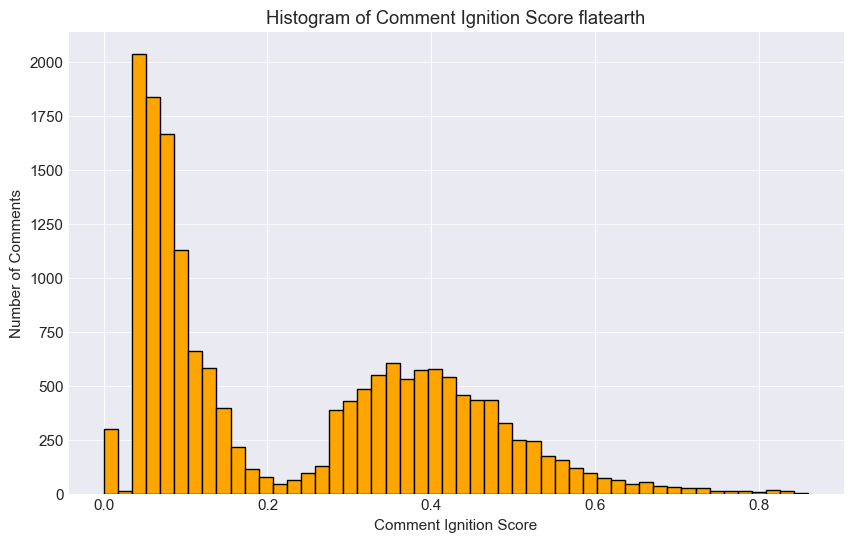

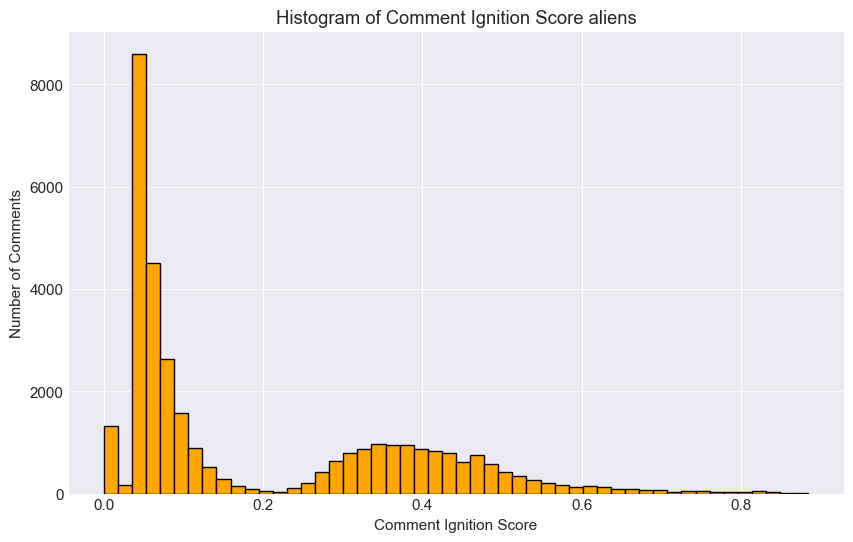

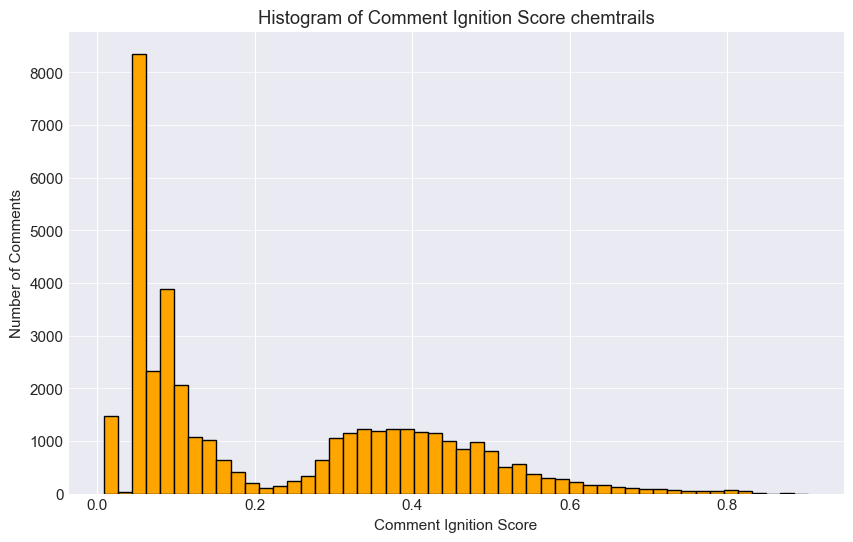

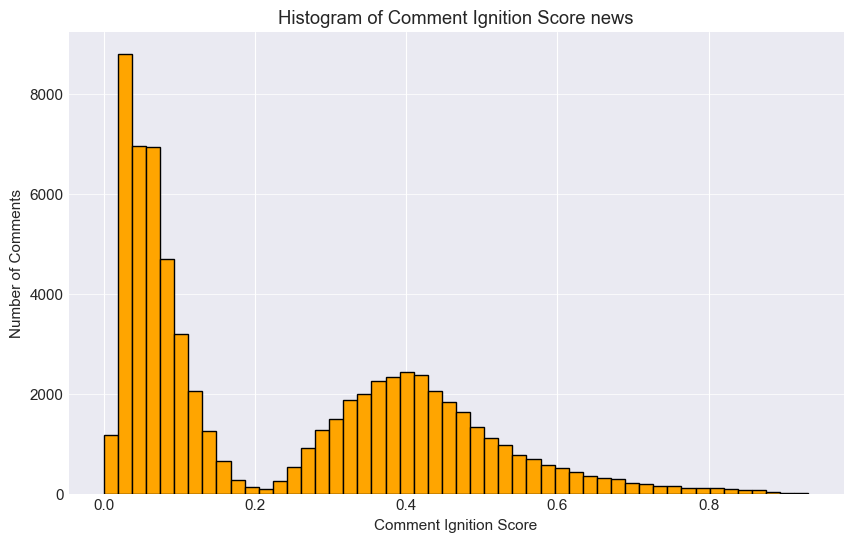

In [157]:
import matplotlib.pyplot as plt

for name, comments in comments_df_dict.items():
    plt.figure(figsize=(10,6))
    plt.hist(comments['comment_ignition_score'], bins=50, color='orange', edgecolor='black')
    plt.title(f'Histogram of Comment Ignition Score {name}')
    plt.xlabel('Comment Ignition Score')
    plt.ylabel('Number of Comments')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

## 🔗 ETAP 2: Data Engineering - Rekonstrukcja Sieci Interakcji

**Problem:** Kolumna `parent_id` wskazuje na activity_id rodzica, ale nie mamy bezpośrednio informacji o autorze, do którego kierowany jest komentarz.

**Rozwiązanie:** Tworzymy mapowanie `activity_id → author`, a następnie dla każdego komentarza znajdujemy `target_author` przez lookup `parent_id`.

In [158]:
for name, df in dataframes.items():
    print(name)
    print(df.shape)

flatearth
(17606, 16)
aliens
(34030, 16)
chemtrails
(39657, 16)
news
(68703, 16)


In [159]:
# KROK 1: Czyszczenie danych - usunięcie botów i usuniętych użytkowników
print("🧹 Czyszczenie danych...")


for name, df in dataframes.items():
    initial_count = len(df)
    df = df[~df['author'].isin(['[deleted]', '[removed]', 'AutoModerator'])].copy()
    df = df[df['author'].notna()].copy()
    dataframes[name] = df

    print(f'\n\n{name}')
    print(f"  Usunięto {initial_count - len(df)} wierszy (boty, usunięci użytkownicy)")
    print(f"  Pozostało: {len(df)} aktywności od {df['author'].nunique()} użytkowników")

🧹 Czyszczenie danych...


flatearth
  Usunięto 2090 wierszy (boty, usunięci użytkownicy)
  Pozostało: 15516 aktywności od 4668 użytkowników


aliens
  Usunięto 5908 wierszy (boty, usunięci użytkownicy)
  Pozostało: 28122 aktywności od 14044 użytkowników


chemtrails
  Usunięto 4820 wierszy (boty, usunięci użytkownicy)
  Pozostało: 34837 aktywności od 8415 użytkowników


news
  Usunięto 18592 wierszy (boty, usunięci użytkownicy)
  Pozostało: 50111 aktywności od 30254 użytkowników


In [160]:
for name, df in dataframes.items():
    print(name)
    print(df.shape)

flatearth
(15516, 16)
aliens
(28122, 16)
chemtrails
(34837, 16)
news
(50111, 16)


In [161]:
# KROK 2: Stworzenie mapowania activity_id → author (SELF-JOIN)
print("🗺️ Tworzenie mapowania interakcji...")

interactions_dict = {}
for name, df in dataframes.items():
    # Słownik: każde activity_id mapuje na swojego autora
    activity_to_author = dict(zip(df['activity_id'], df['author']))

    # Funkcja pomocnicza do znalezienia target_author
    def find_target_author(parent_id):
        """Znajduje autora, do którego skierowana jest odpowiedź"""
        if pd.isna(parent_id) or parent_id == 'N/A':
            return None
        return activity_to_author.get(parent_id, None)

    # Dodanie kolumny target_author do DataFrame
    df['target_author'] = df['parent_id'].apply(find_target_author)
    dataframes[name] = df

    # Statystyki interakcji
    interactions_dict[name] = df[df['target_author'].notna()]
    print(f'\n\n{name}')
    print(f"  ✓ Zrekonstruowano {len(interactions_dict[name])} interakcji między użytkownikami")
    print(f"  ✓ {len(df[df['target_author'].isna()])} aktywności bez target_author (nowe posty)")

🗺️ Tworzenie mapowania interakcji...


flatearth
  ✓ Zrekonstruowano 13515 interakcji między użytkownikami
  ✓ 2001 aktywności bez target_author (nowe posty)


aliens
  ✓ Zrekonstruowano 22974 interakcji między użytkownikami
  ✓ 5148 aktywności bez target_author (nowe posty)


chemtrails
  ✓ Zrekonstruowano 30305 interakcji między użytkownikami
  ✓ 4532 aktywności bez target_author (nowe posty)


news
  ✓ Zrekonstruowano 35951 interakcji między użytkownikami
  ✓ 14160 aktywności bez target_author (nowe posty)


In [162]:
# KROK 3: Budowa skierowanego grafu (DiGraph) z wagami
print("🕸️ Budowa grafu interakcji...")

graphs_dict = {}

for name, df in dataframes.items():
    G = nx.DiGraph()

    # Dodanie wszystkich użytkowników jako węzłów
    all_users = set(df['author'].unique())
    G.add_nodes_from(all_users)

    # Dodanie krawędzi: author → target_author (komentarz/odpowiedź)
    # Z wagami: zliczamy ile razy A odpowiada B
    edges = []
    for _, row in interactions_dict[name].iterrows():
        if row['target_author'] and row['author'] != row['target_author']:
            edges.append((row['author'], row['target_author']))

    # Zliczanie wag (ile razy użytkownik A odpowiedział użytkownikowi B)
    edge_weights = Counter(edges)

    for (u, v), weight in edge_weights.items():
        G.add_edge(u, v, weight=weight)

    graphs_dict[name] = G

    print(f'\n\n{name}')
    print(f"  ✓ Graf utworzony:")
    print(f"    - Węzły (użytkownicy): {G.number_of_nodes()}")
    print(f"    - Krawędzie (interakcje): {G.number_of_edges()}")
    print(f"    - Krawędzie ważone: tak (max waga: {max(edge_weights.values())})")
    print(f"    - Średni stopień węzła: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

🕸️ Budowa grafu interakcji...


flatearth
  ✓ Graf utworzony:
    - Węzły (użytkownicy): 4668
    - Krawędzie (interakcje): 9827
    - Krawędzie ważone: tak (max waga: 20)
    - Średni stopień węzła: 4.21


aliens
  ✓ Graf utworzony:
    - Węzły (użytkownicy): 14044
    - Krawędzie (interakcje): 20246
    - Krawędzie ważone: tak (max waga: 22)
    - Średni stopień węzła: 2.88


chemtrails
  ✓ Graf utworzony:
    - Węzły (użytkownicy): 8415
    - Krawędzie (interakcje): 23637
    - Krawędzie ważone: tak (max waga: 34)
    - Średni stopień węzła: 5.62


news
  ✓ Graf utworzony:
    - Węzły (użytkownicy): 30254
    - Krawędzie (interakcje): 32904
    - Krawędzie ważone: tak (max waga: 11)
    - Średni stopień węzła: 2.18


## 🔬 ETAP 3: Feature Engineering - Profilowanie Użytkowników

Dla każdego użytkownika wyliczamy zestaw cech, które posłużą do klasteryzacji:
- **Aktywność:** liczba postów, komentarzy, stosunek post/comment
- **Sieć:** in-degree, out-degree, PageRank
- **Sentyment:** średnia i odchylenie standardowe (VADER)
- **Kontrowersja:** średnie upvote_ratio i score

In [163]:
# Przygotowanie analizatora sentymentu
print("💭 Inicjalizacja analizy sentymentu (VADER)...")
sia = SentimentIntensityAnalyzer()

# Import tqdm dla paska postępu
from tqdm.notebook import tqdm
tqdm.pandas()

def get_sentiment(text):
    """Zwraca wynik sentymentu (compound score od -1 do 1)"""
    if pd.isna(text) or text == '[deleted]':
        return 0.0
    try:
        return sia.polarity_scores(str(text))['compound']
    except:
        return 0.0

for name, df in dataframes.items():
    # Dodanie kolumny sentymentu do DataFrame z paskiem postępu
    print("  Obliczanie sentymentu dla wszystkich wypowiedzi...")
    df['sentiment'] = df['content'].apply(get_sentiment)
    print(f"  ✓ Sentiment score: min={df['sentiment'].min():.2f}, max={df['sentiment'].max():.2f}, mean={df['sentiment'].mean():.2f}")

💭 Inicjalizacja analizy sentymentu (VADER)...
  Obliczanie sentymentu dla wszystkich wypowiedzi...
  ✓ Sentiment score: min=-0.99, max=1.00, mean=0.04
  Obliczanie sentymentu dla wszystkich wypowiedzi...
  ✓ Sentiment score: min=-1.00, max=1.00, mean=0.06
  Obliczanie sentymentu dla wszystkich wypowiedzi...
  ✓ Sentiment score: min=-1.00, max=1.00, mean=0.02
  Obliczanie sentymentu dla wszystkich wypowiedzi...
  ✓ Sentiment score: min=-1.00, max=1.00, mean=-0.06


In [164]:
for name, _df in dataframes.items():
    comments_df = comments_df_dict[name]
    post_ts = (
        _df[_df['activity_type'] == 'post']
        .set_index('activity_id')['timestamp']
    )

    mask = (comments_df['parent_comment_timestamp'].isna()) & (comments_df['parent_type'] == 'post')

    comments_df.loc[mask, 'parent_comment_timestamp'] = comments_df.loc[mask, 'parent_id'].map(post_ts)

    # recompute reply_delay_sec ONLY for those rows
    comments_df.loc[mask, 'reply_delay_sec'] = (
        comments_df.loc[mask, 'timestamp']
        - comments_df.loc[mask, 'parent_comment_timestamp']
    ).dt.total_seconds()

In [165]:
for name, df in dataframes.items():
    comments_df = comments_df_dict[name]
    shape_before = len(comments_df)
    _df = comments_df[comments_df['parent_comment_timestamp'].notna()]
    print(f'{name}: dropped {shape_before-len(_df)} comments without parent timestamp, {len(_df)} comments remain')
    comments_df_dict[name] = _df

flatearth: dropped 559 comments without parent timestamp, 16611 comments remain
aliens: dropped 1965 comments without parent timestamp, 31684 comments remain
chemtrails: dropped 867 comments without parent timestamp, 38355 comments remain
news: dropped 2538 comments without parent timestamp, 65703 comments remain


In [181]:
# Wyliczanie cech dla każdego użytkownika
print("📊 Wyliczanie cech użytkowników...")

users_dict = {}

for name, df in dataframes.items():

    user_features = {}
    G = graphs_dict[name]
    comments_df = comments_df_dict[name]

    for author in df['author'].unique():
        user_data = df[df['author'] == author]
        user_comments = comments_df[comments_df['author'] == author]

        if len(user_comments) == 0:
            continue #skip users without comments
        
        # 1. CECHY AKTYWNOŚCI
        num_posts = len(user_data[user_data['activity_type'] == 'post'])
        num_comments = len(user_data[user_data['activity_type'] == 'comment'])
        avg_replies = user_comments['num_replies'].mean() if len(user_comments) > 0 else 0
        avg_comment_delay = user_comments['reply_delay_sec'].mean()
        avg_replies_delay = user_comments['median_reply_seconds'].mean()

    
        # 2. CECHY SIECIOWE
        in_degree = G.in_degree(author) if author in G else 0  # Ile osób mu odpisuje (autorytet)
        out_degree = G.out_degree(author) if author in G else 0  # Ile on odpisuje innym

        weighted_in_degree = G.in_degree(author, weight='weight') if author in G else 0
        weighted_out_degree = G.out_degree(author, weight='weight') if author in G else 0
        
        # 3. CECHY SENTYMENTU
        sentiments = user_data['sentiment'].dropna()
        avg_sentiment = sentiments.mean() if len(sentiments) > 0 else 0
        std_sentiment = sentiments.std() if len(sentiments) > 1 else 0
        
        # 4. CECHY KONTROWERSJI
        # upvote_ratio blisko 0.5 = duża kontrowersja (równe up i downvotes)
        ratios = user_data['upvote_ratio'].dropna()
        avg_upvote_ratio = ratios.mean() if len(ratios) > 0 else 0.5
        
        scores = user_data['score'].dropna()
        avg_score = scores.mean() if len(scores) > 0 else 0
        
        user_features[author] = {
            'num_posts': num_posts,
            'num_comments': num_comments,
            'avg_replies': avg_replies,
            'avg_comment_delay': avg_comment_delay,
            'avg_replies_delay': avg_replies_delay,
            'in_degree': in_degree,
            'out_degree': out_degree,
            'weighted_out_degree': weighted_out_degree,
            'weighted_in_degree': weighted_in_degree,
            'avg_sentiment': avg_sentiment,
            'std_sentiment': std_sentiment,
            'avg_upvote_ratio': avg_upvote_ratio,
            'avg_score': avg_score
        }

    # Konwersja do DataFrame
    user_df = pd.DataFrame.from_dict(user_features, orient='index')
    users_dict[name] = user_df

    print(f'\n\n{name}')
    print(f"  ✓ Wyliczono cechy dla {len(user_df)} użytkowników")
    print(f"\n📈 Przegląd statystyk:")
    print(user_df.describe().T)

📊 Wyliczanie cech użytkowników...


flatearth
  ✓ Wyliczono cechy dla 4469 użytkowników

📈 Przegląd statystyk:
                      count          mean           std      min  \
num_posts            4469.0  7.003804e-02  5.944909e-01   0.0000   
num_comments         4469.0  3.356456e+00  7.888820e+00   1.0000   
avg_replies          4469.0  4.733468e-01  7.416383e-01   0.0000   
avg_comment_delay    4469.0  8.232023e+05  8.375270e+06   2.5000   
avg_replies_delay    4469.0  4.692754e+07  6.160396e+07  19.5000   
in_degree            4469.0  2.102484e+00  8.981567e+00   0.0000   
out_degree           4469.0  2.198926e+00  4.033936e+00   0.0000   
weighted_out_degree  4469.0  3.006489e+00  7.001452e+00   0.0000   
weighted_in_degree   4469.0  2.909376e+00  1.273095e+01   0.0000   
avg_sentiment        4469.0  3.337832e-02  3.577562e-01  -0.9753   
std_sentiment        4469.0  1.654576e-01  2.349654e-01   0.0000   
avg_upvote_ratio     4469.0  5.006793e-01  1.047668e-02   0.3800   
avg_s

## drop users without comments

In [182]:
for name, df in users_dict.items():
    print(df.shape)

(4469, 13)
(13130, 13)
(8128, 13)
(28836, 13)


In [172]:
# for name, df in users_dict.items():
#     shape_before = len(df)
#     _df = df[df['num_comments'] > 0]
#     print(f'{name}: dropped {shape_before-len(_df)} users without comments, {len(_df)} users remain')
#     #users_dict[name] = _df

flatearth: dropped 0 users without comments, 4469 users remain


In [ ]:
comments_df_dict['flatearth'].head()

In [ ]:
_df.head()

In [170]:
_df = comments_df_dict['flatearth']
# _df[(_df['parent_comment_timestamp'].isna()) & (_df['parent_type'] == 'post')]
_df[_df['author'] == 'OddCockpitSpacer']

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,...,post_id,parent_comments_ids,parent_comment_timestamp,num_replies,reply_delay_sec,median_reply_seconds,replies_log,score_log,speed_inv,comment_ignition_score


In [178]:
# # users_dict['flatearth'][(users_dict['flatearth']['num_comments'] == 0)].shape
# users_dict['news'][(users_dict['news']['avg_replies_delay'].isna())]

,num_posts,num_comments,avg_replies,avg_comment_delay,avg_replies_delay,in_degree,out_degree,weighted_out_degree,avg_sentiment,std_sentiment,avg_upvote_ratio,avg_score


In [183]:
# Dodanie PageRank (autorytet w sieci)
print("🏆 Obliczanie PageRank...")

# PageRank wymaga grafu z przynajmniej jedną krawędzią
for name, df in dataframes.items():
    G = graphs_dict[name]
    user_df = users_dict[name]
    if G.number_of_edges() > 0:
        pagerank = nx.pagerank(G, alpha=0.85)
        user_df['pagerank'] = user_df.index.map(pagerank).fillna(0)
    else:
        user_df['pagerank'] = 0

    users_dict[name] = user_df
    print(f"  ✓ PageRank: top użytkownik ma score {user_df['pagerank'].max():.6f}")
    print(f"\n🎯 TOP 10 użytkowników wg PageRank:")
    user_df.nlargest(10, 'pagerank')[['in_degree', 'out_degree', 'pagerank']]

🏆 Obliczanie PageRank...
  ✓ PageRank: top użytkownik ma score 0.016997

🎯 TOP 10 użytkowników wg PageRank:
  ✓ PageRank: top użytkownik ma score 0.014086

🎯 TOP 10 użytkowników wg PageRank:
  ✓ PageRank: top użytkownik ma score 0.015870

🎯 TOP 10 użytkowników wg PageRank:
  ✓ PageRank: top użytkownik ma score 0.003545

🎯 TOP 10 użytkowników wg PageRank:


## 🎯 ETAP 5: Klasteryzacja Użytkowników (K-Means)

Wykorzystamy wyliczone cechy do identyfikacji ról użytkowników przez grupowanie (clustering).

In [184]:
# Przygotowanie danych do klasteryzacji
print("🎯 Przygotowanie danych do klasteryzacji...")

# user_features[author] = {
#     'num_posts': num_posts,
#     'num_comments': num_comments,
#     'avg_replies': avg_replies,
#     'avg_comment_delay': avg_comment_delay,
#     'avg_replies_delay': avg_replies_delay,
#     'in_degree': in_degree,
#     'out_degree': out_degree,
#     'weighted_out_degree': weighted_out_degree,
#     'weighted_in_degree': weighted_in_degree,
#     'avg_sentiment': avg_sentiment,
#     'std_sentiment': std_sentiment,
#     'avg_upvote_ratio': avg_upvote_ratio,
#     'avg_score': avg_score
# }

# Wybór cech do klastrowania
feature_cols = [
    'num_posts', 'num_comments', 
    'avg_replies', 'avg_comment_delay', 'avg_replies_delay',
    'in_degree', 'out_degree', 'weighted_out_degree', 'weighted_in_degree', 'pagerank',
    'avg_sentiment', 'std_sentiment',
    'avg_upvote_ratio', 'avg_score'
]

Xs_dict = {}

for name, user_df in users_dict.items():

    X = user_df[feature_cols].copy()

    if X.isna().any().any():
        raise ValueError(f"NaNs found in features for {name}")

    # Standaryzacja (ważne dla K-Means!)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    Xs_dict[name] = X_scaled

    print(f'\n\n{name}')
    print(f"  ✓ Dane przygotowane: {X_scaled.shape[0]} użytkowników × {X_scaled.shape[1]} cech")

🎯 Przygotowanie danych do klasteryzacji...


flatearth
  ✓ Dane przygotowane: 4469 użytkowników × 14 cech


aliens
  ✓ Dane przygotowane: 13130 użytkowników × 14 cech


chemtrails
  ✓ Dane przygotowane: 8128 użytkowników × 14 cech


news
  ✓ Dane przygotowane: 28836 użytkowników × 14 cech


📐 Metoda łokcia dla wyboru liczby klastrów...


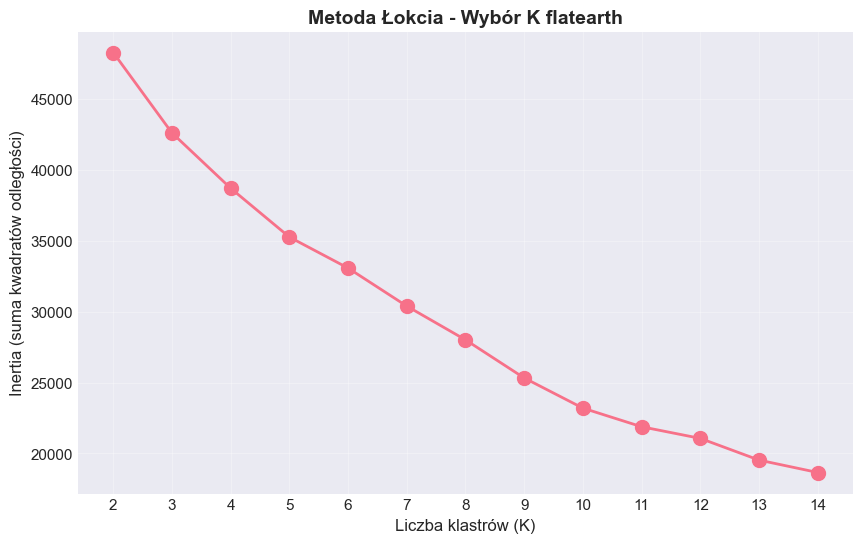

  ℹ️ Szukaj 'łokcia' na wykresie - punkt przegięcia krzywej


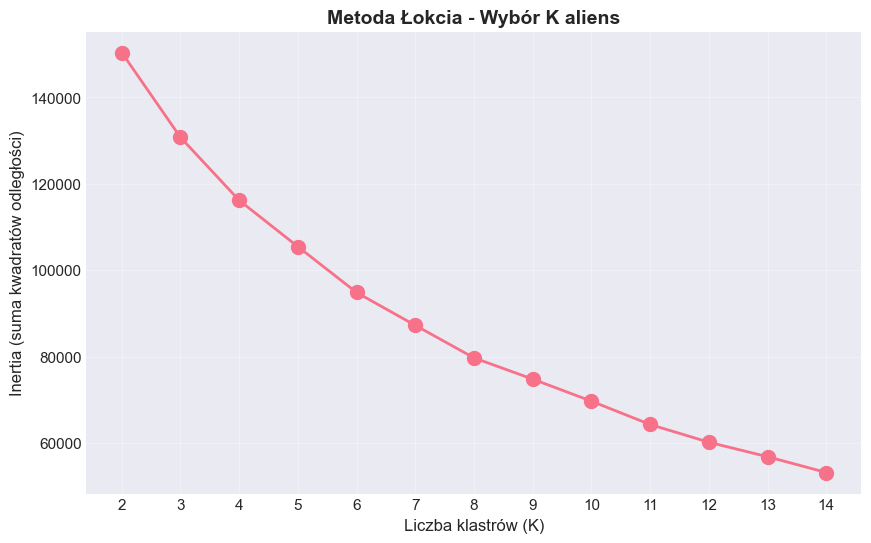

  ℹ️ Szukaj 'łokcia' na wykresie - punkt przegięcia krzywej


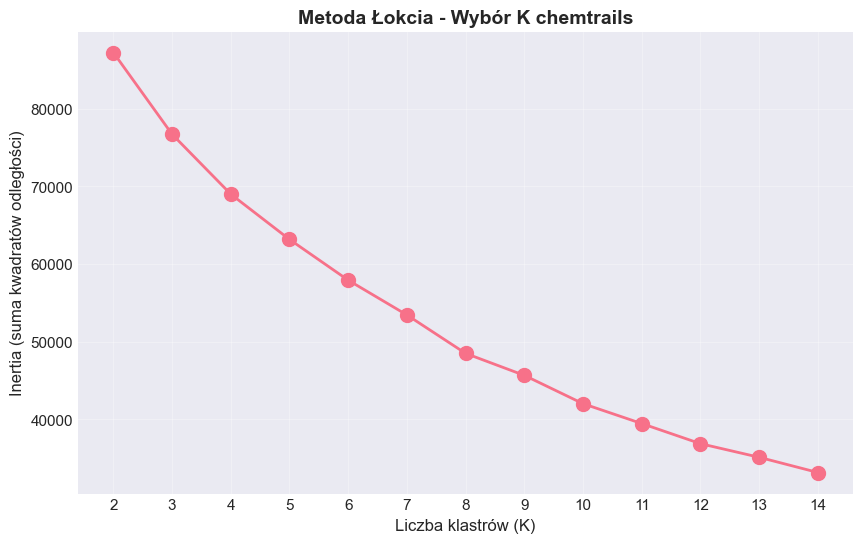

  ℹ️ Szukaj 'łokcia' na wykresie - punkt przegięcia krzywej


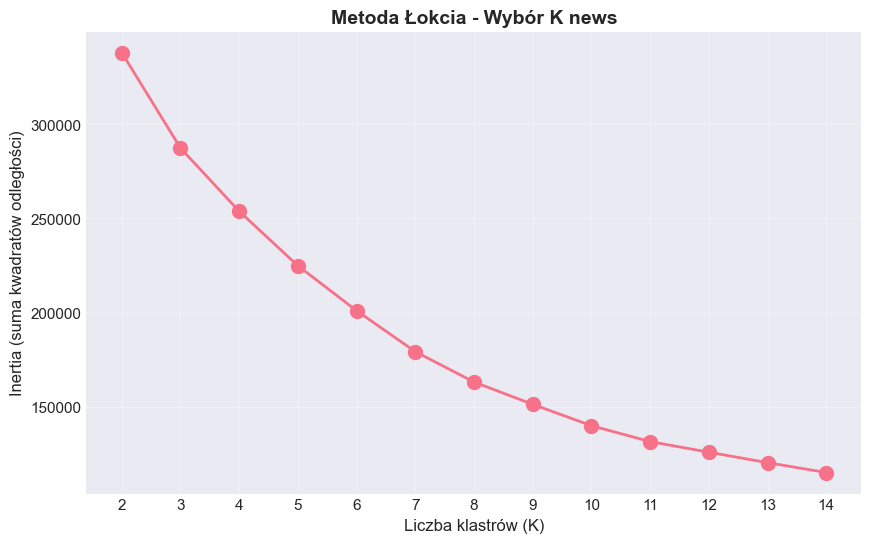

  ℹ️ Szukaj 'łokcia' na wykresie - punkt przegięcia krzywej


In [185]:
# Metoda łokcia - wybór optymalnej liczby klastrów
print("📐 Metoda łokcia dla wyboru liczby klastrów...")

for name, X_scaled in Xs_dict.items():

    inertias = []
    K_range = range(2, 15)

    for k in K_range:
        kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans_temp.fit(X_scaled)
        inertias.append(kmeans_temp.inertia_)

    plt.figure(figsize=(10, 6))
    plt.plot(K_range, inertias, marker='o', linewidth=2, markersize=10)
    plt.xlabel('Liczba klastrów (K)', fontsize=12)
    plt.ylabel('Inertia (suma kwadratów odległości)', fontsize=12)
    plt.title(f'Metoda Łokcia - Wybór K {name}', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.xticks(K_range)
    plt.savefig('../notebooks/elbow_method.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("  ℹ️ Szukaj 'łokcia' na wykresie - punkt przegięcia krzywej")

In [189]:
# K-Means z 8 klastrami (zmień jeśli metoda łokcia sugeruje inną wartość)
print("🔬 Uruchomienie K-Means (K=8)...")

n_clusters = 8
kmeans_dict = {}

for name, user_df in users_dict.items():
    X_scaled = Xs_dict[name]
    kmeans = KMeans(n_clusters=n_clusters, random_state=123)
    user_df['cluster'] = kmeans.fit_predict(X_scaled)
    kmeans_dict[name] = kmeans

    print(f'\n\n{name}')
    print(f"  ✓ Klasteryzacja zakończona")
    print(f"\n📊 Rozkład użytkowników w klastrach:")
    print(user_df['cluster'].value_counts().sort_index())

🔬 Uruchomienie K-Means (K=8)...


flatearth
  ✓ Klasteryzacja zakończona

📊 Rozkład użytkowników w klastrach:
cluster
0     955
1       7
2     475
3    1149
4     123
5      19
6      18
7    1723
Name: count, dtype: int64


aliens
  ✓ Klasteryzacja zakończona

📊 Rozkład użytkowników w klastrach:
cluster
0    7058
1    2683
2    3164
3      12
4      21
5     106
6      85
7       1
Name: count, dtype: int64


chemtrails
  ✓ Klasteryzacja zakończona

📊 Rozkład użytkowników w klastrach:
cluster
0    3334
1       5
2    1366
3      15
4    1142
5     142
6      11
7    2113
Name: count, dtype: int64


news
  ✓ Klasteryzacja zakończona

📊 Rozkład użytkowników w klastrach:
cluster
0     4825
1    14759
2      286
3        9
4       27
5     8798
6      119
7       13
Name: count, dtype: int64


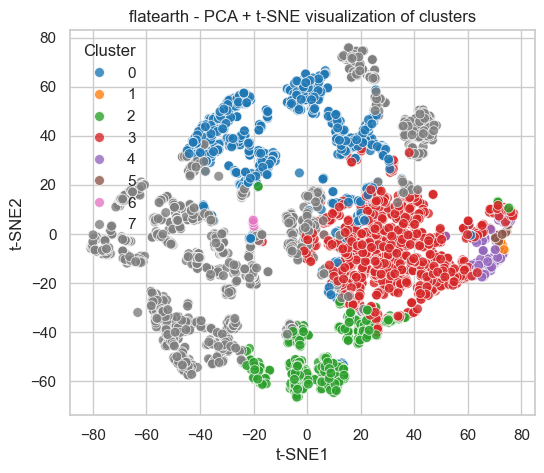

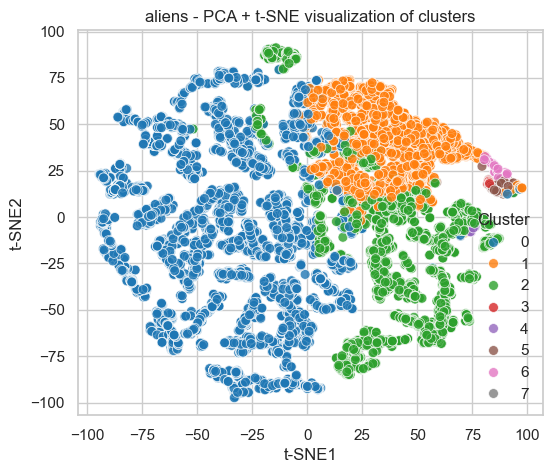

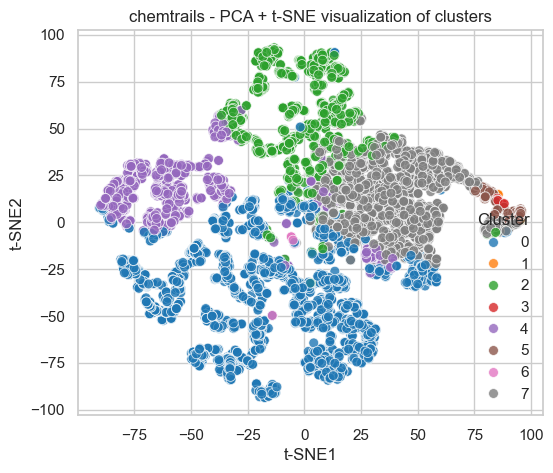

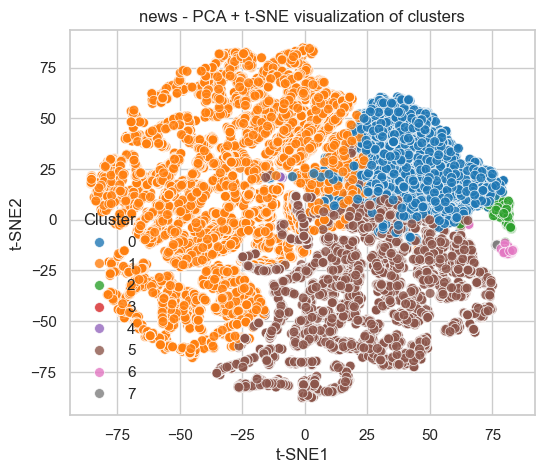

In [201]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

for name, X_scaled in Xs_dict.items():
    user_df = users_dict[name]
    
    X_pca = PCA(n_components=10, random_state=123).fit_transform(X_scaled)
    
    tsne = TSNE(
        n_components=2, 
        perplexity=30, 
        learning_rate=200, 
        random_state=123,
        init='pca'
    )
    X_tsne = tsne.fit_transform(X_pca)
    
    plt.figure(figsize=(6,5))
    sns.scatterplot(
        x=X_tsne[:,0],
        y=X_tsne[:,1],
        hue=user_df['cluster'],
        palette='tab10',
        s=50,
        alpha=0.8
    )
    plt.title(f"{name} - PCA + t-SNE visualization of clusters")
    plt.xlabel("t-SNE1")
    plt.ylabel("t-SNE2")
    plt.legend(title='Cluster')
    plt.show()


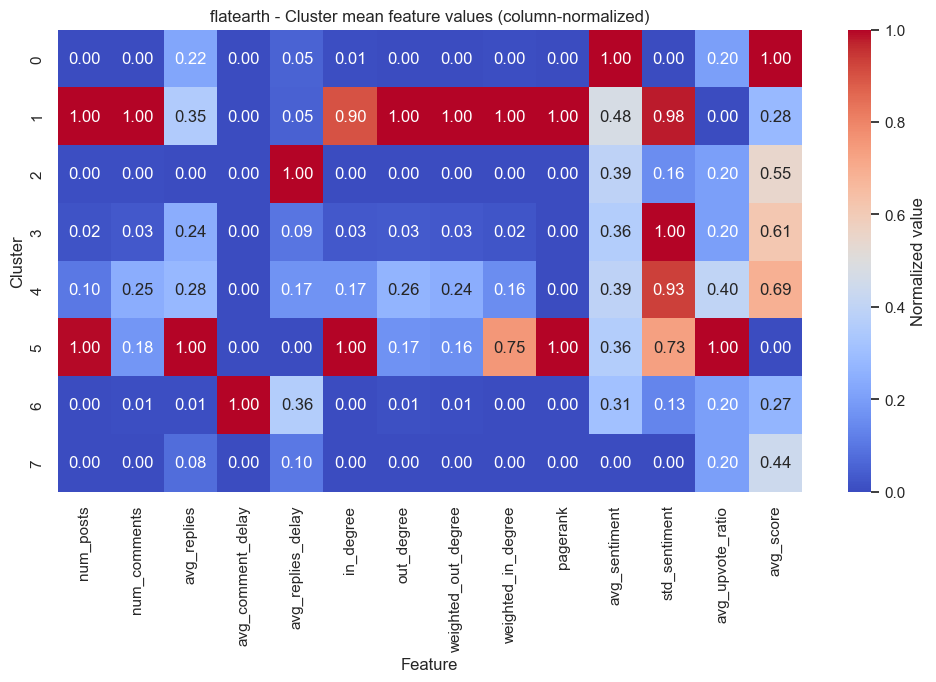

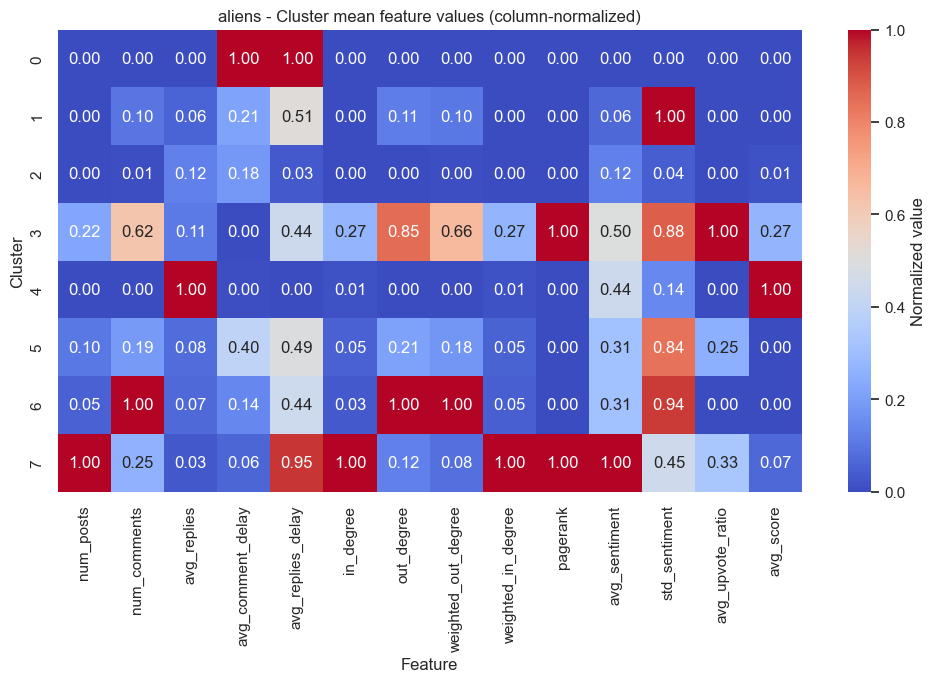

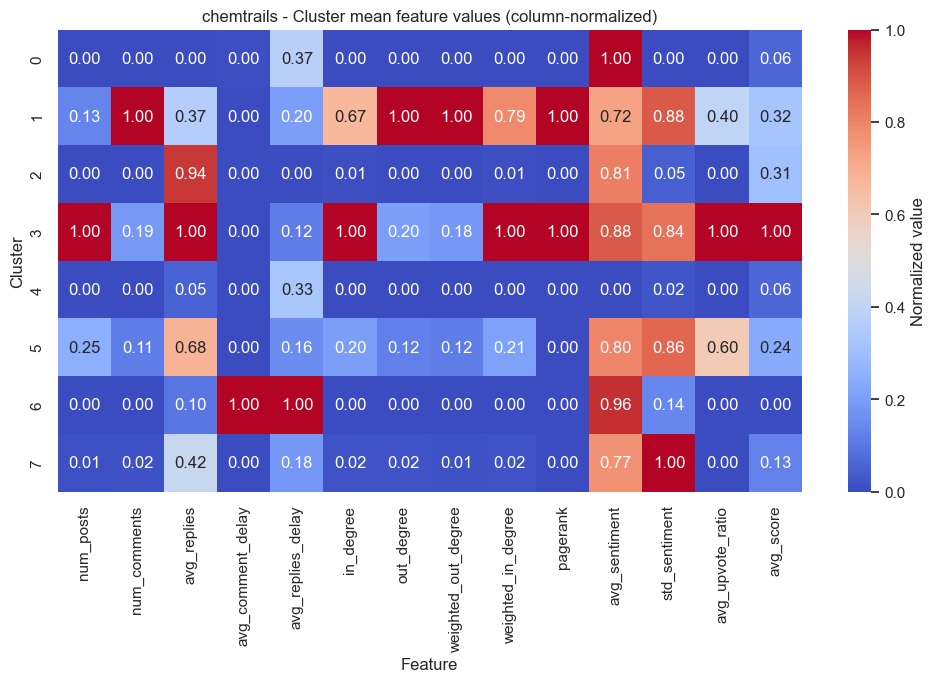

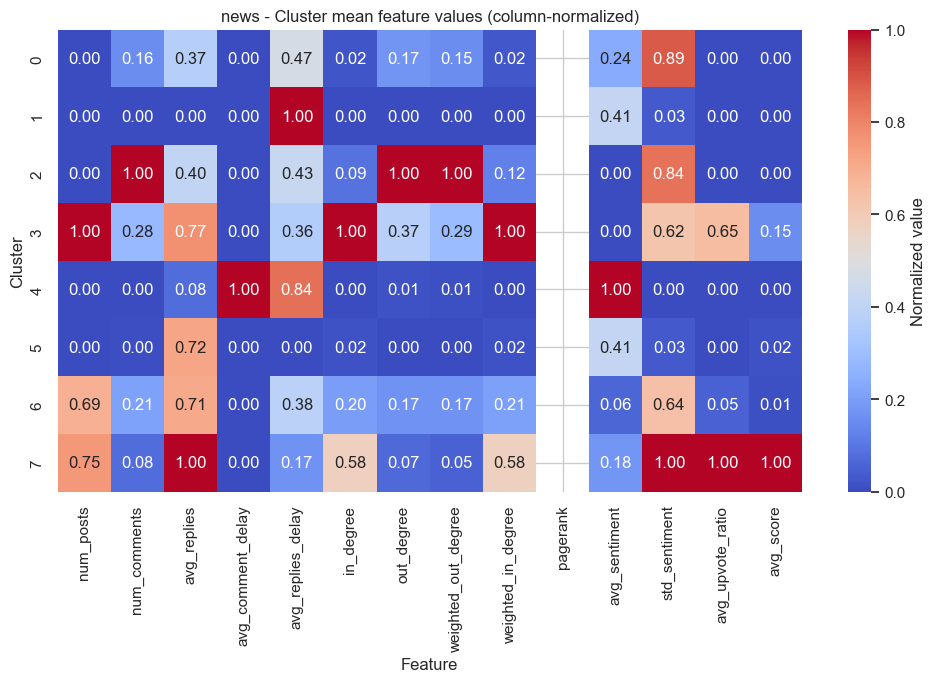

In [204]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cluster_stats_dict = {}

for name, user_df in users_dict.items():
    stats = (
        user_df.groupby('cluster')[feature_cols]
        .agg(['mean', 'std', 'median', 'min', 'max', 'count'])
        .round(2)
    )
    cluster_stats_dict[name] = stats

for name, stats in cluster_stats_dict.items():
    mean_stats = stats.xs('mean', level=1, axis=1)
    
    mean_stats_norm = (mean_stats - mean_stats.min()) / (mean_stats.max() - mean_stats.min())
    
    plt.figure(figsize=(12,6))
    sns.heatmap(
        mean_stats_norm,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        cbar_kws={'label': 'Normalized value'}
    )
    plt.title(f"{name} - Cluster mean feature values (column-normalized)")
    plt.ylabel("Cluster")
    plt.xlabel("Feature")
    plt.show()

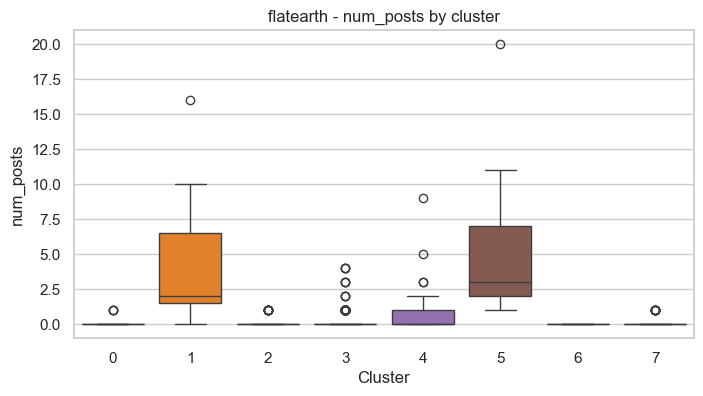

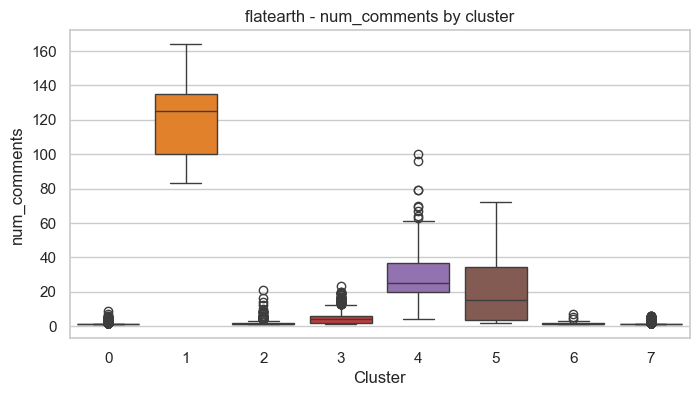

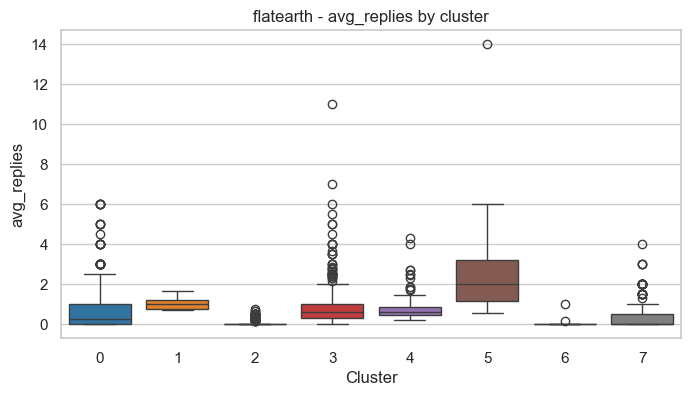

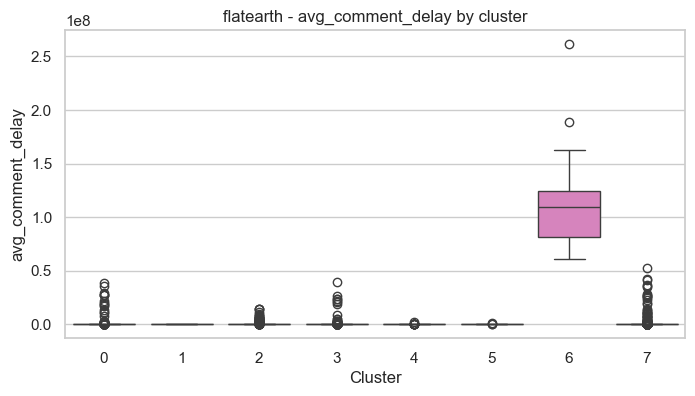

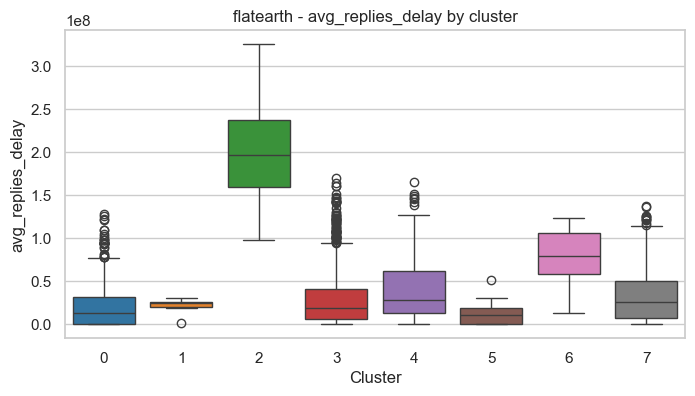

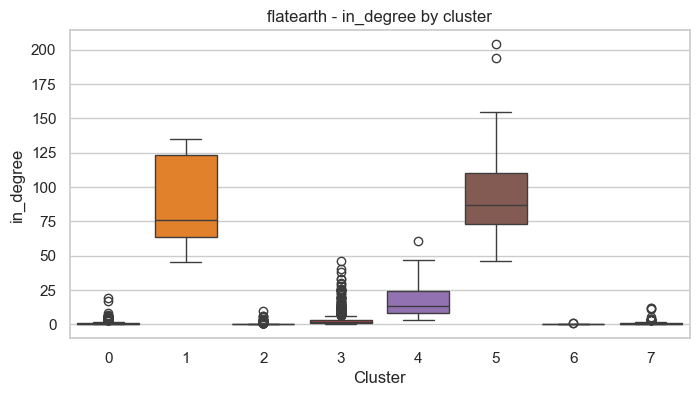

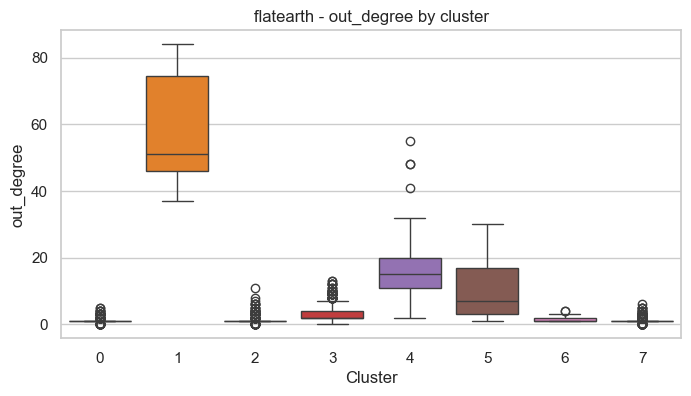

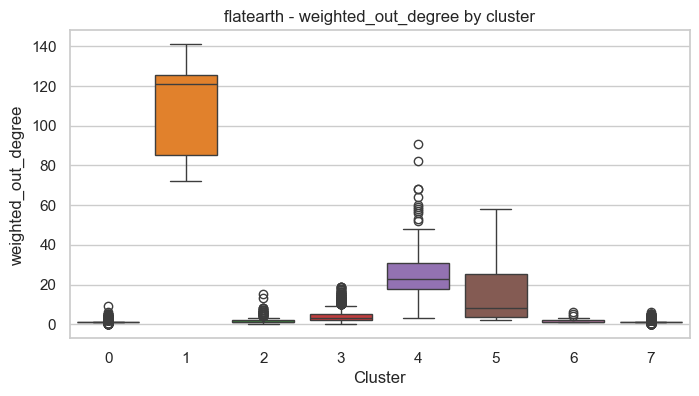

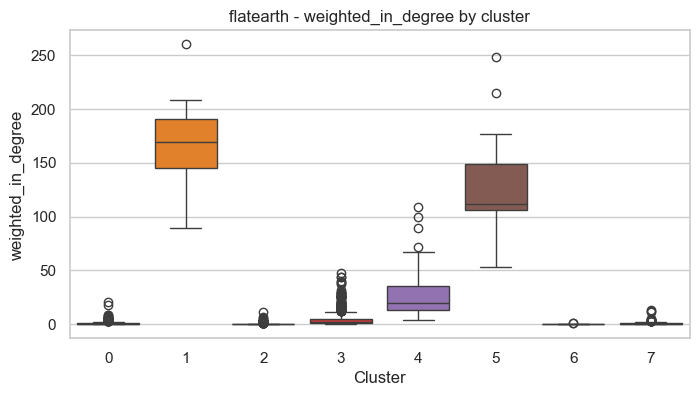

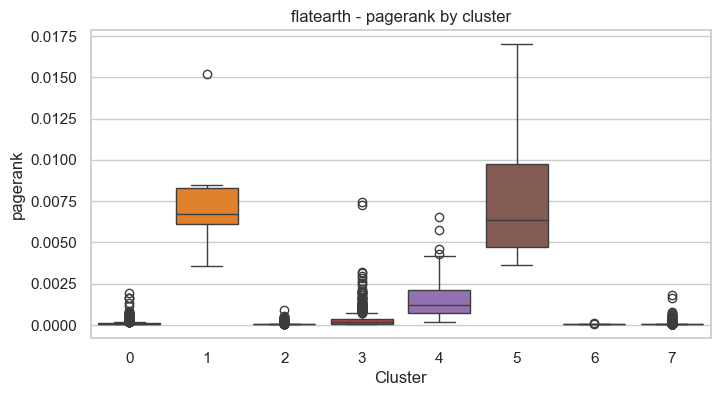

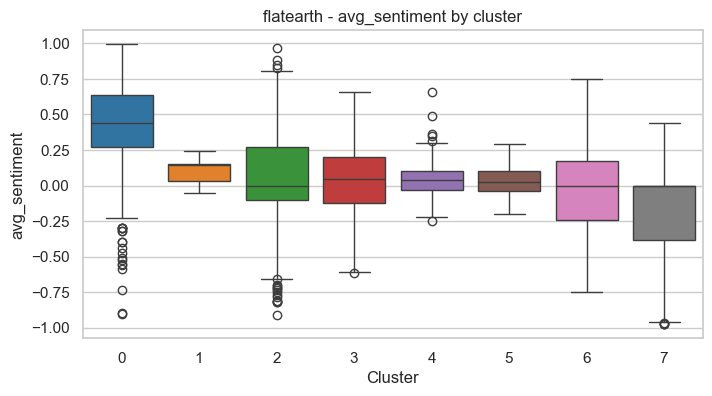

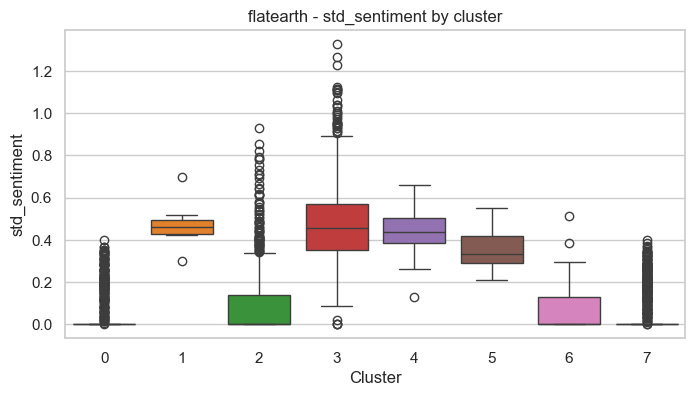

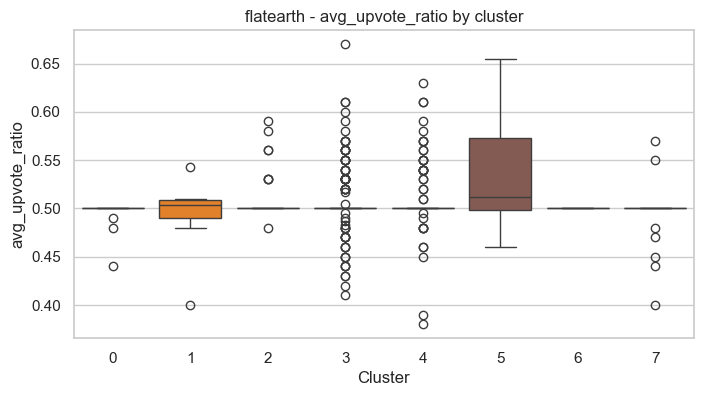

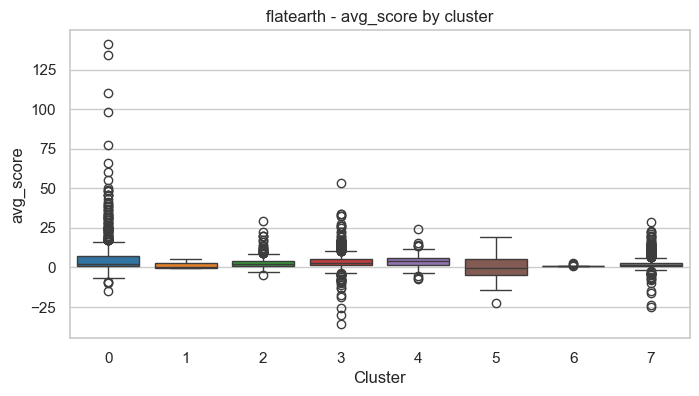

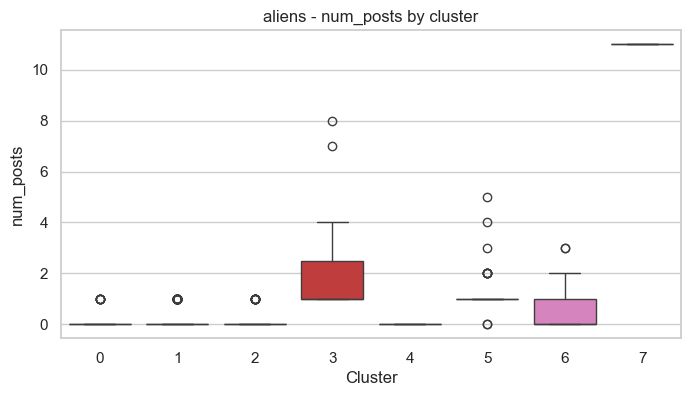

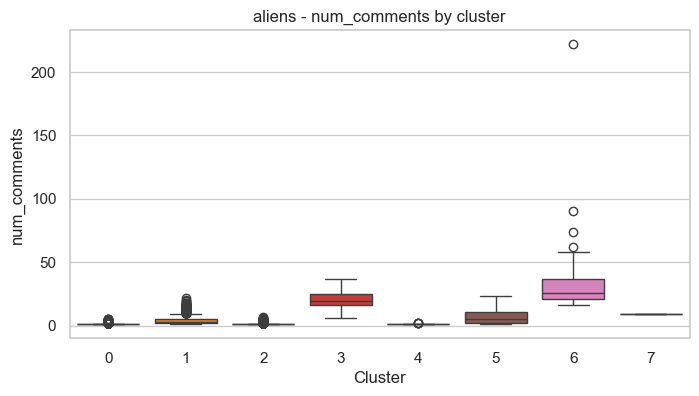

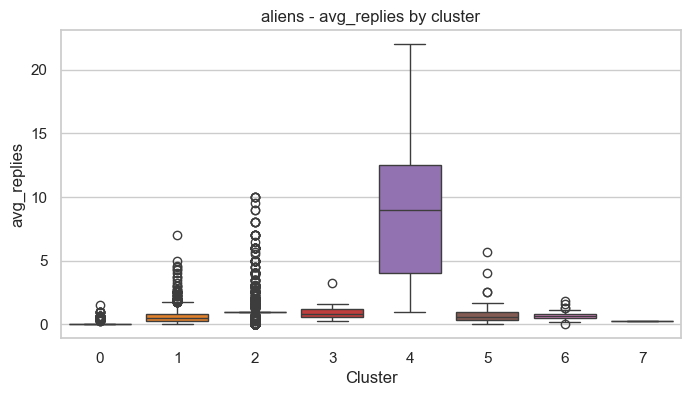

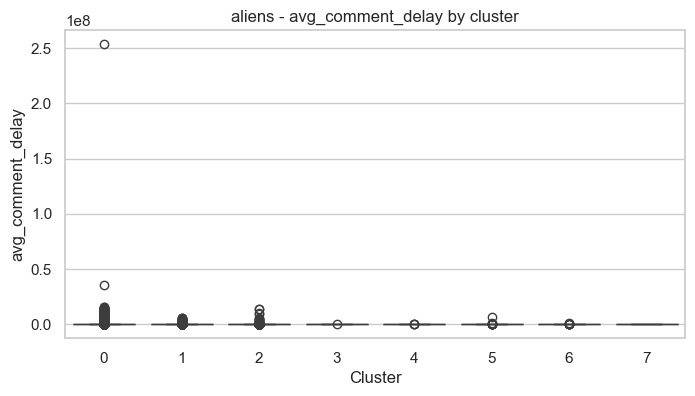

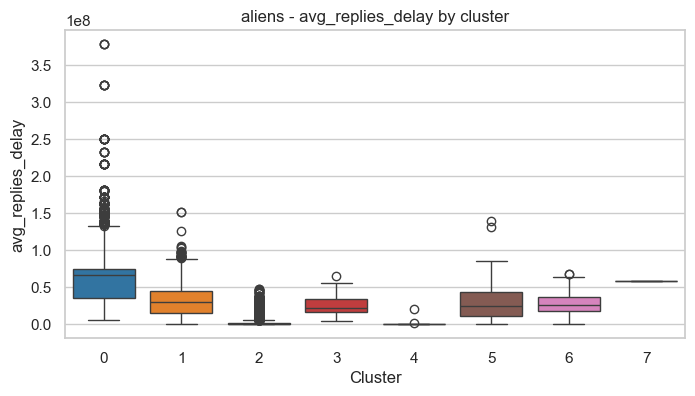

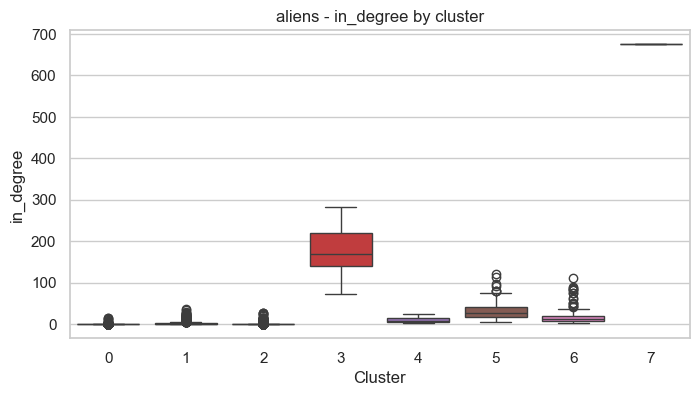

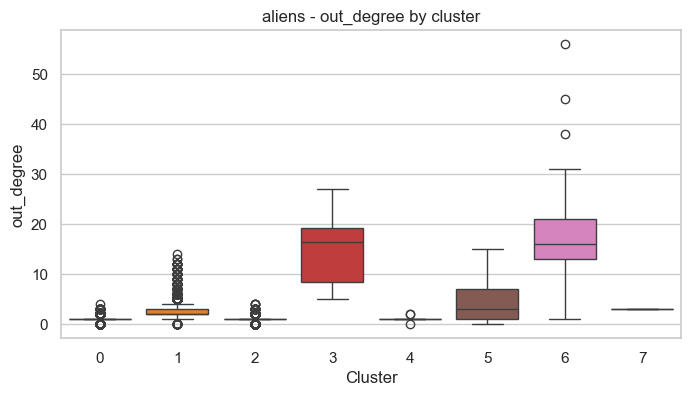

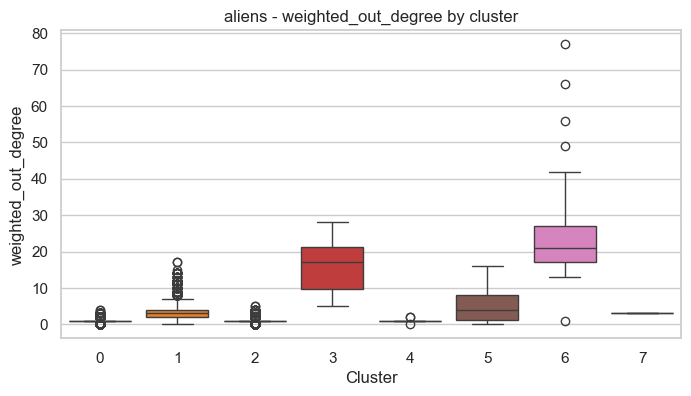

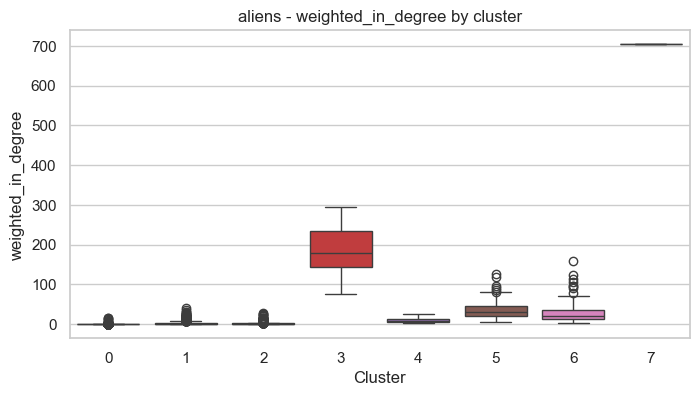

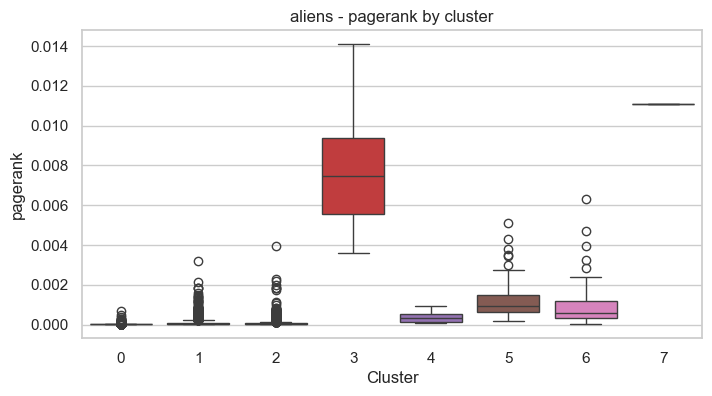

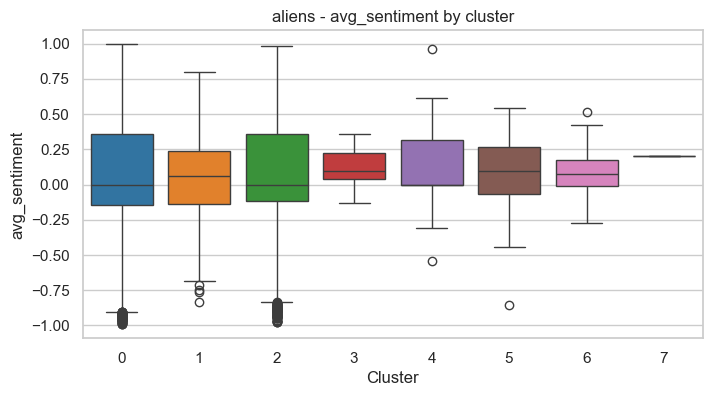

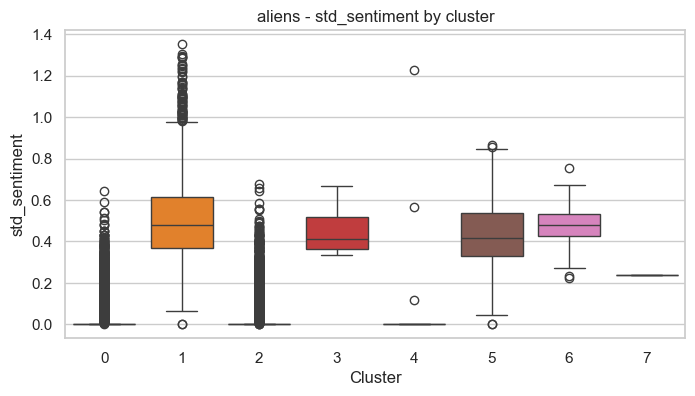

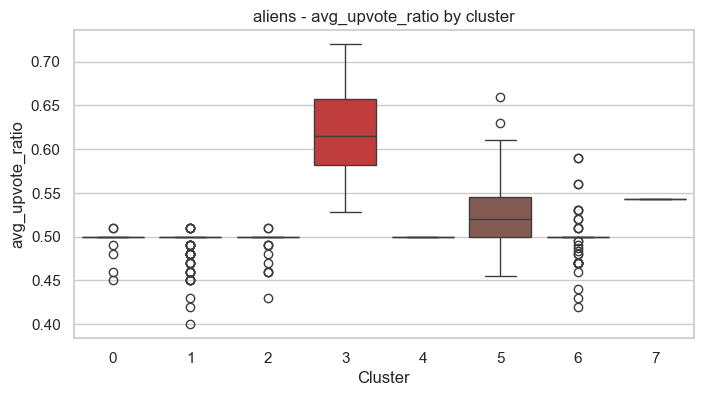

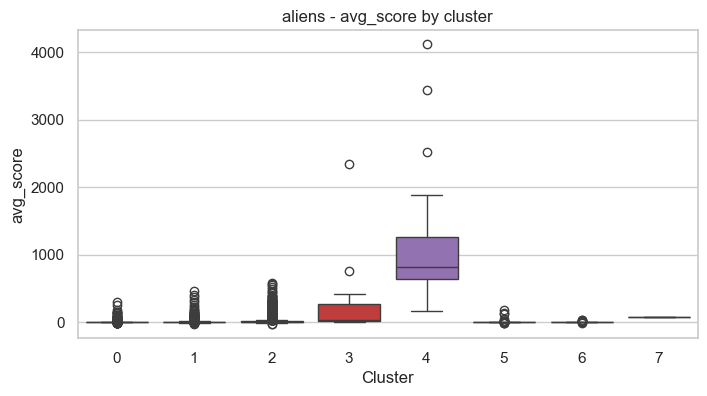

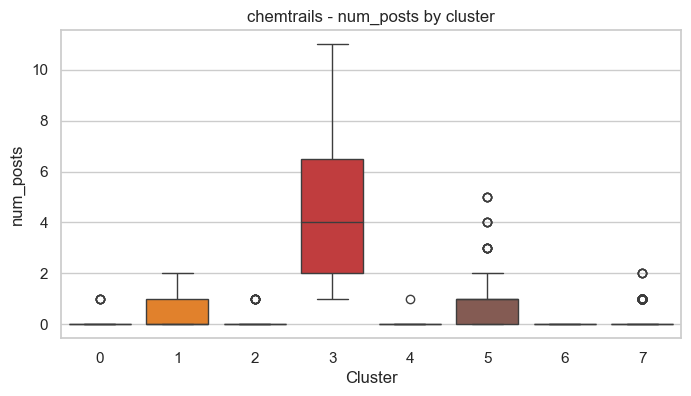

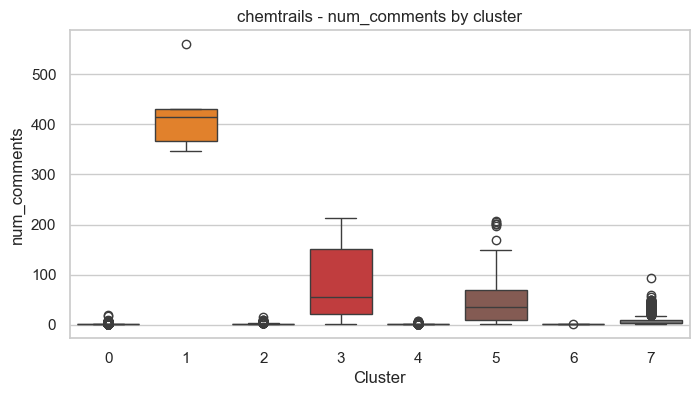

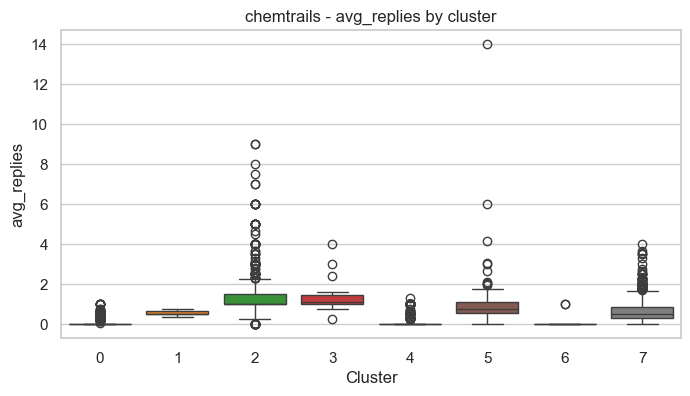

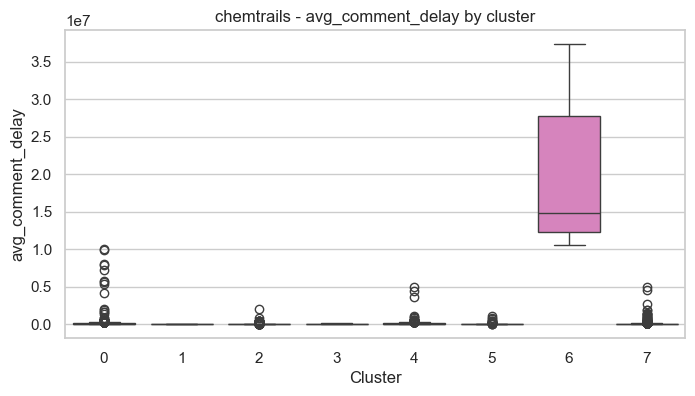

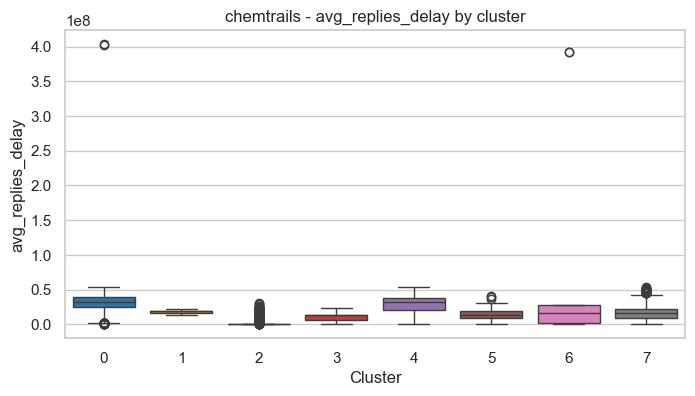

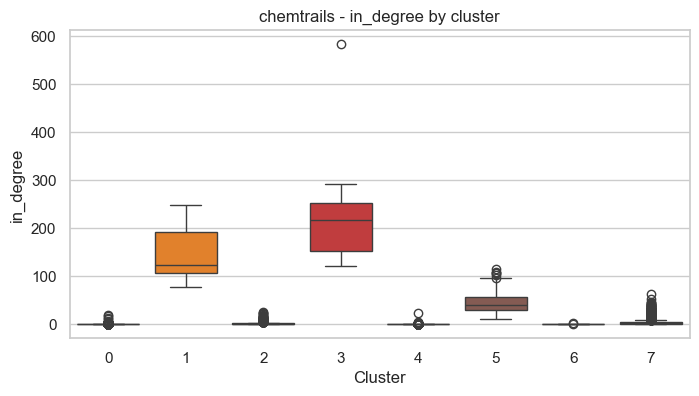

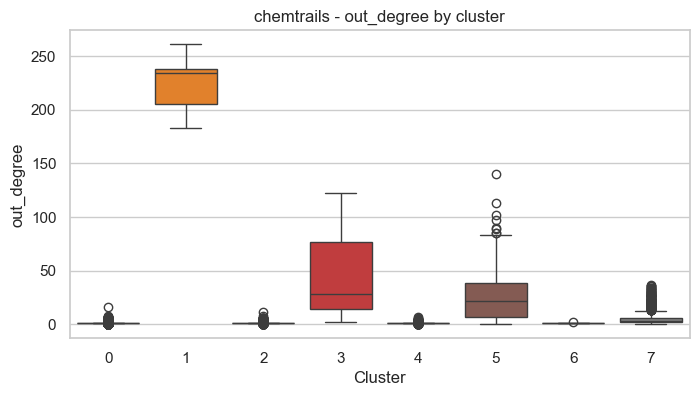

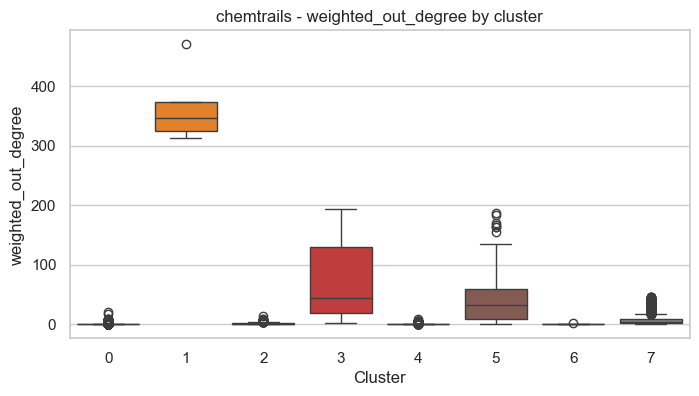

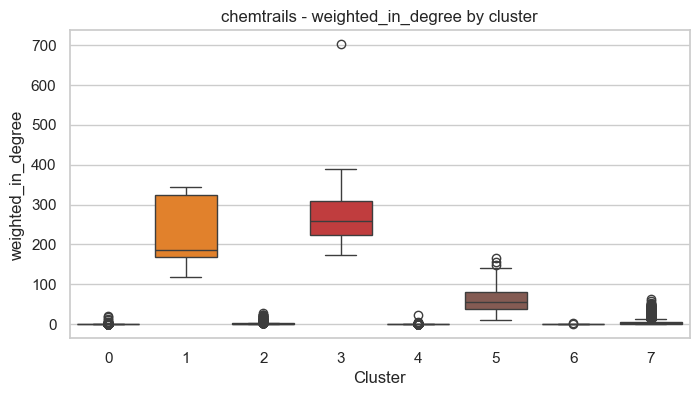

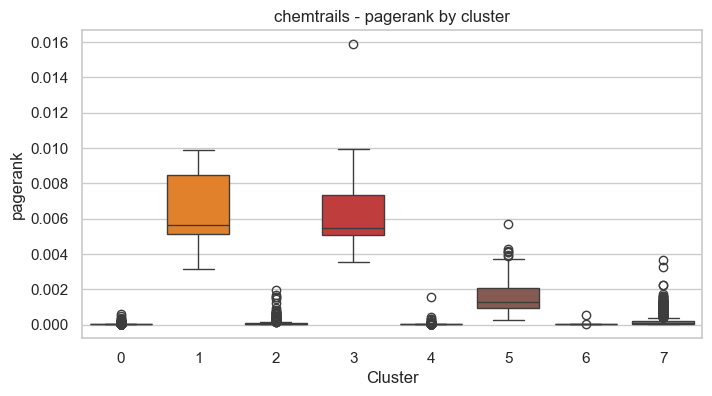

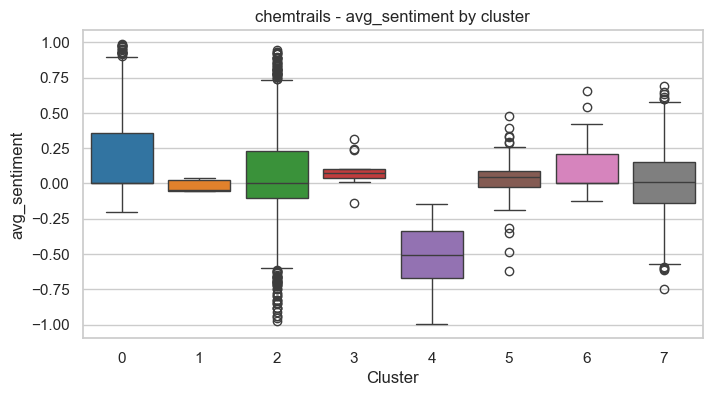

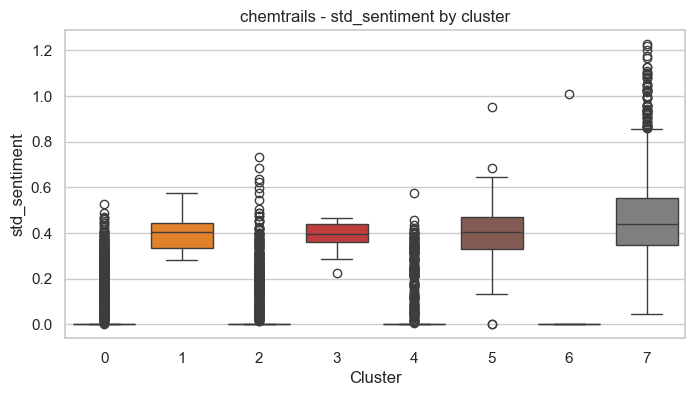

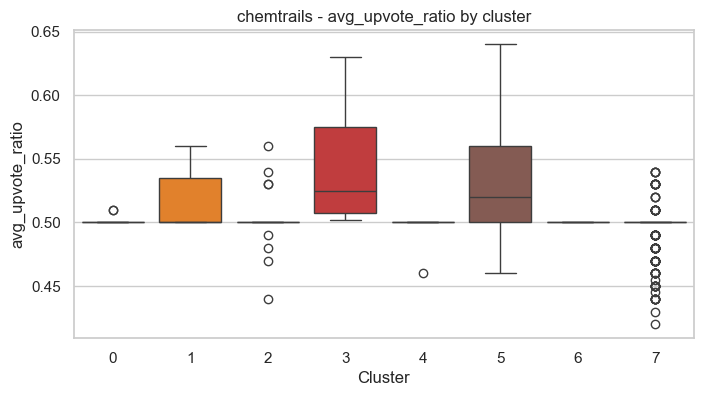

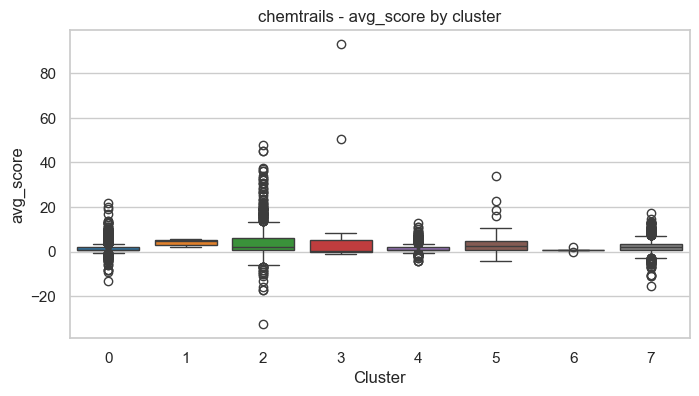

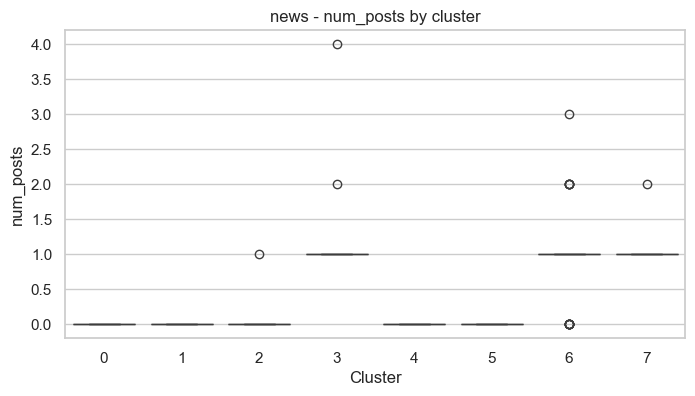

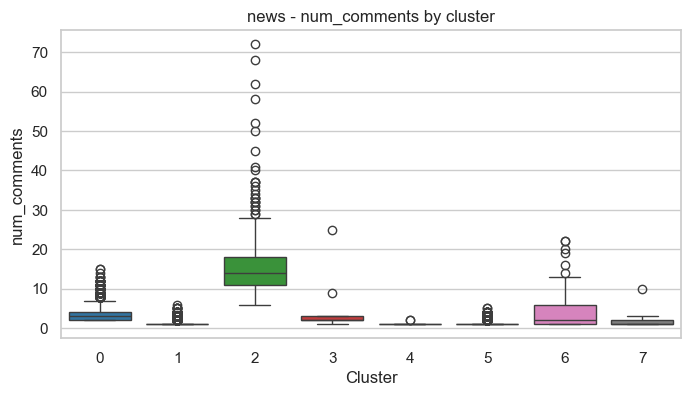

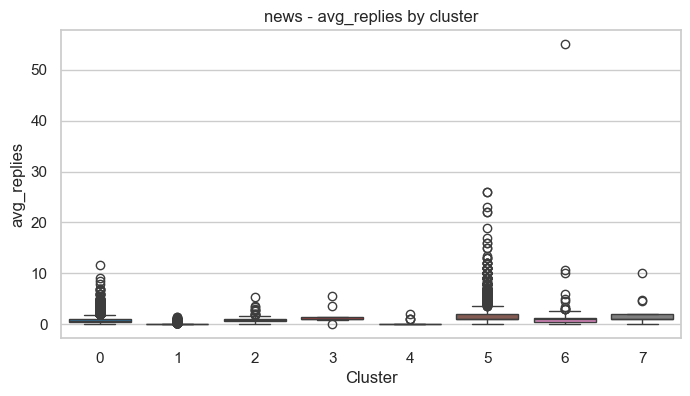

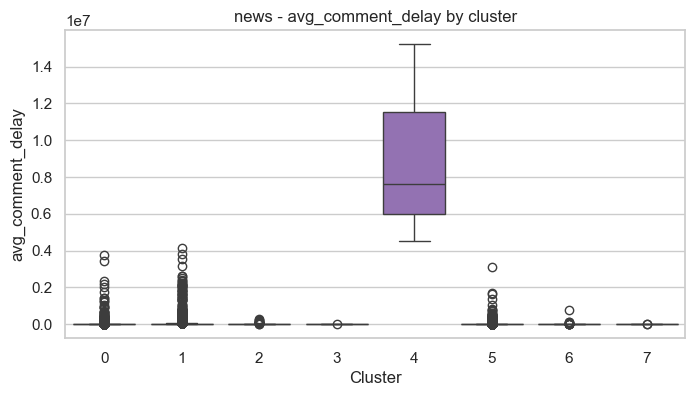

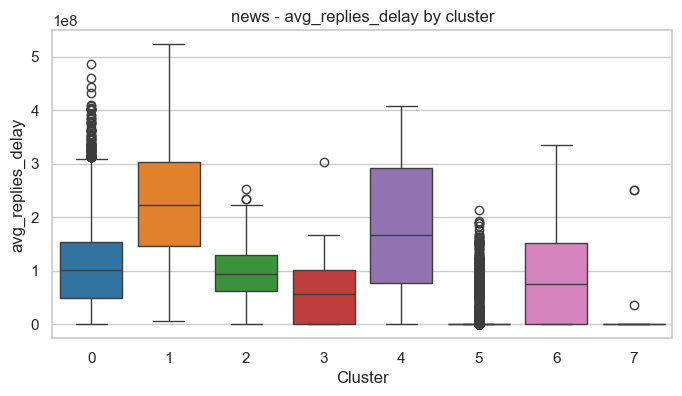

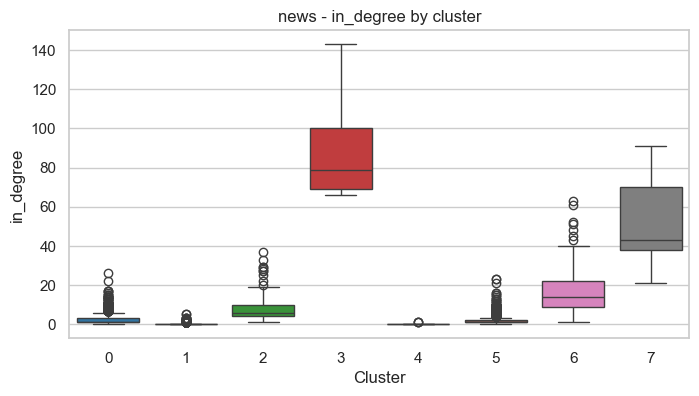

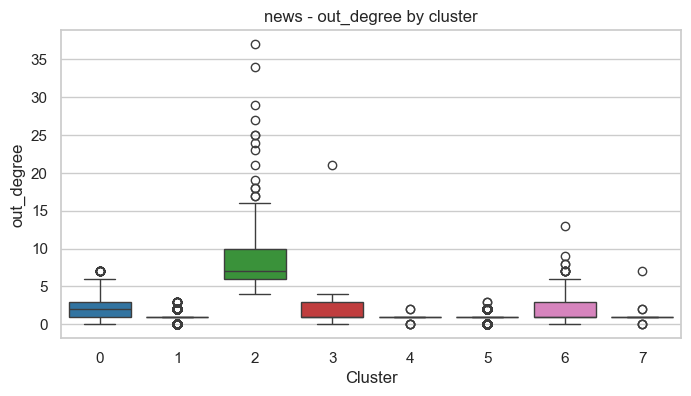

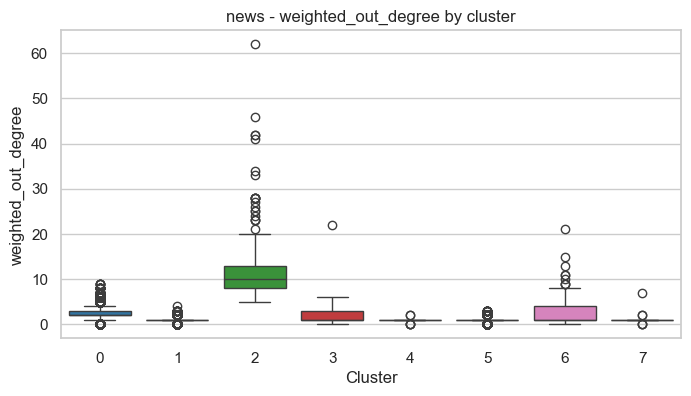

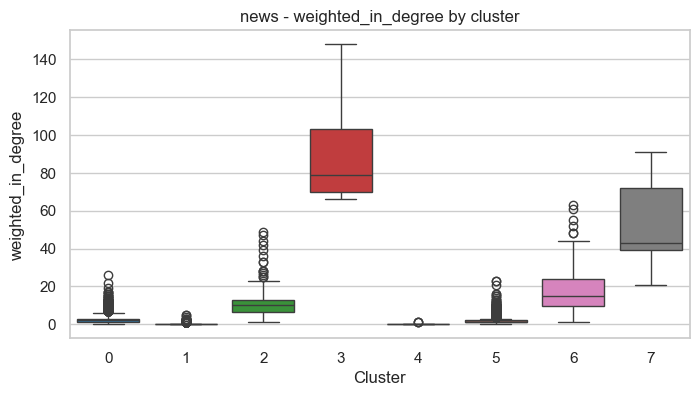

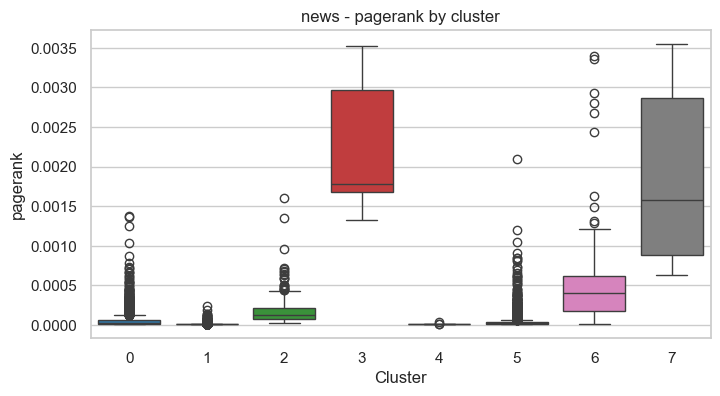

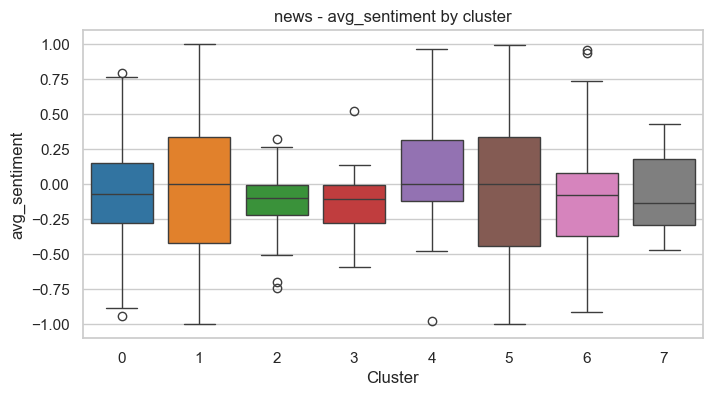

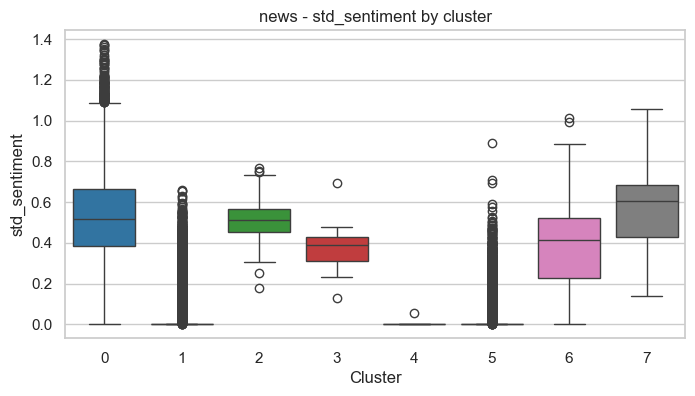

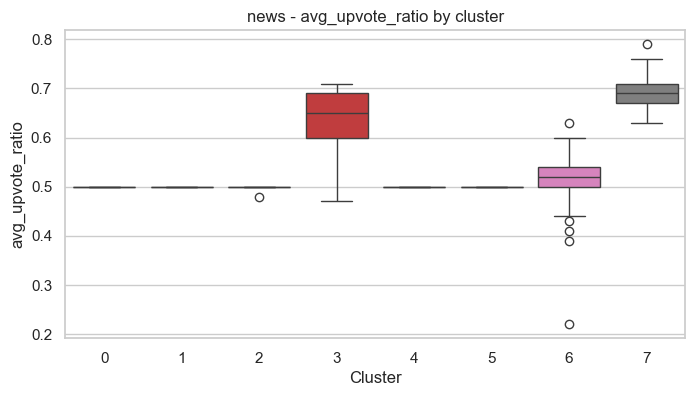

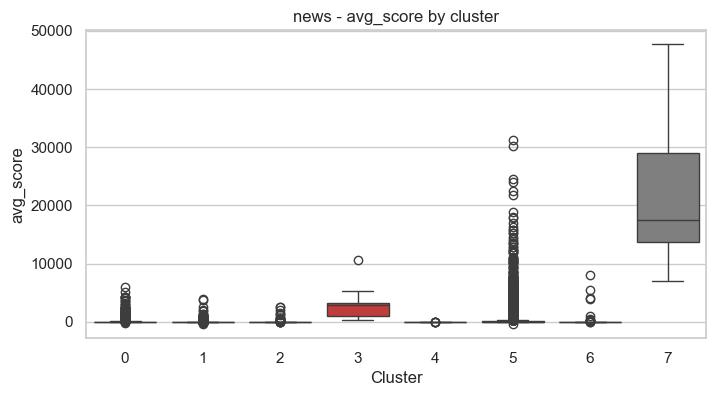

In [203]:
for name, user_df in users_dict.items():
    for feature in feature_cols:
        plt.figure(figsize=(8,4))
        sns.boxplot(x='cluster', y=feature, data=user_df, palette='tab10')
        plt.title(f"{name} - {feature} by cluster")
        plt.xlabel("Cluster")
        plt.ylabel(feature)
        plt.show()


In [222]:
cluster_centroids = {}
for name, stats in cluster_stats_dict.items():
    stats = stats.drop('pagerank', axis=1)
    cluster_centroids[name] = stats.xs('mean', level=1, axis=1)

In [223]:
for name, stats in cluster_centroids.items():
    cluster_centroids[name] = (stats - stats.min()) / (stats.max() - stats.min())

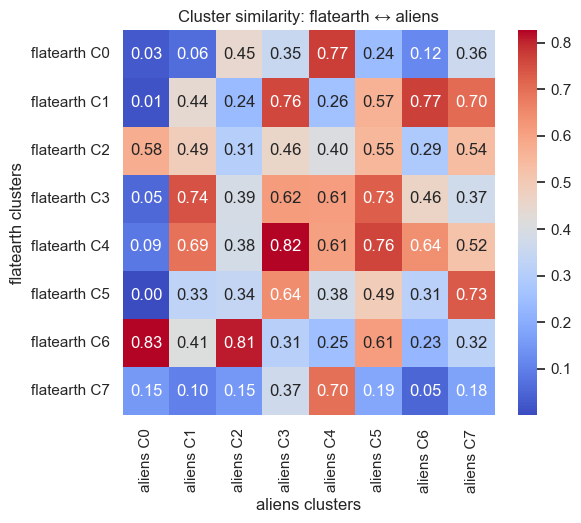

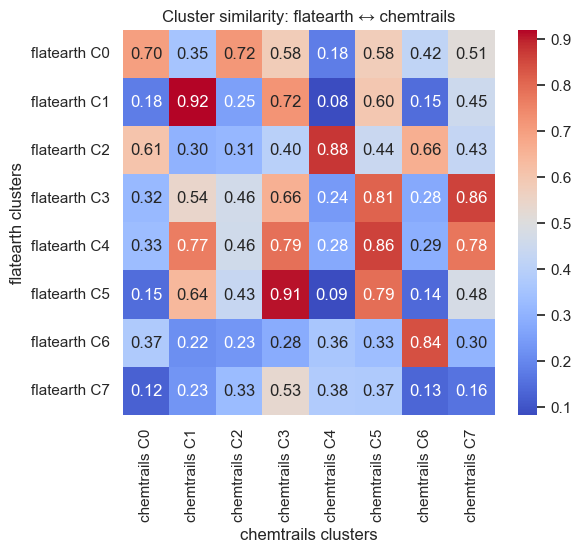

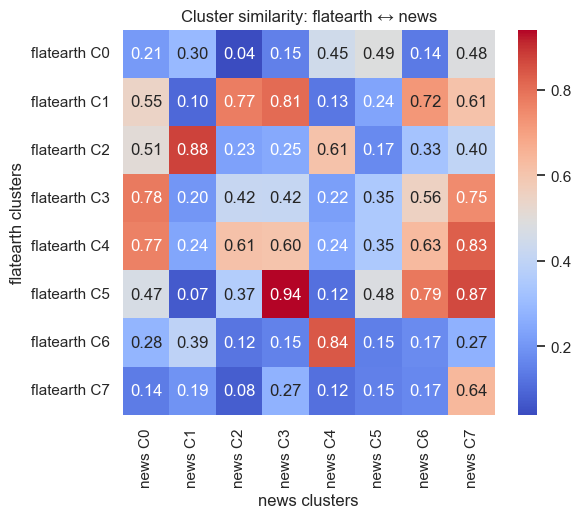

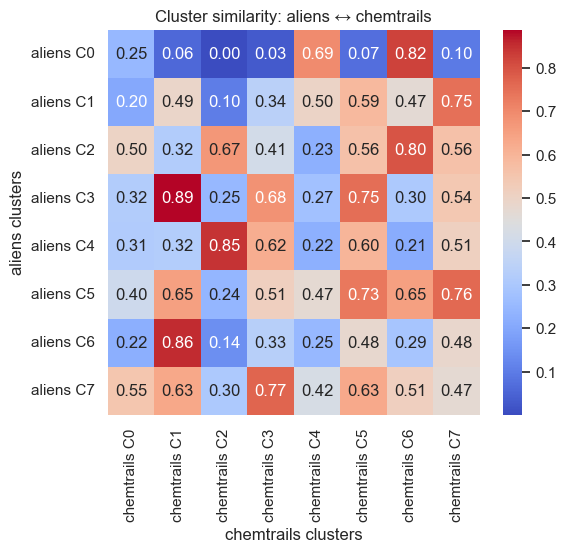

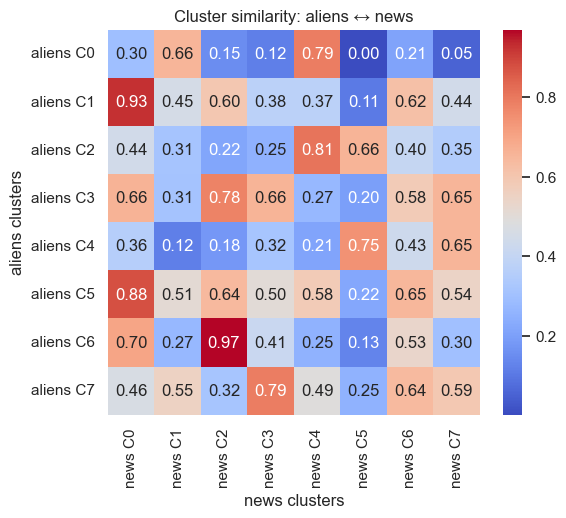

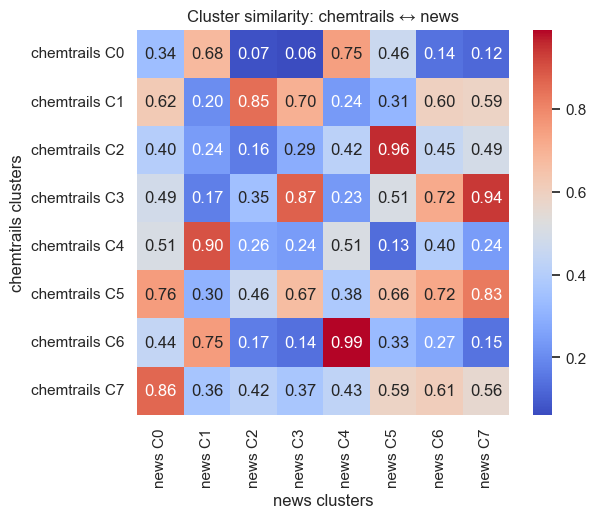

In [225]:
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity

subreddit_names = list(cluster_centroids.keys())
pairs = list(combinations(subreddit_names, 2))

for sub1, sub2 in pairs:
    centroids1 = cluster_centroids[sub1]
    centroids2 = cluster_centroids[sub2]
    
    sim_matrix = cosine_similarity(centroids1, centroids2)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(
        sim_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        xticklabels=[f"{sub2} C{i}" for i in range(centroids2.shape[0])],
        yticklabels=[f"{sub1} C{i}" for i in range(centroids1.shape[0])]
    )
    plt.title(f"Cluster similarity: {sub1} ↔ {sub2}")
    plt.xlabel(f"{sub2} clusters")
    plt.ylabel(f"{sub1} clusters")
    plt.show()


In [232]:
cluster_avg_score_dict = {}

for name, user_df in users_dict.items():
    comments_df = comments_df_dict[name]
    
    comments_with_cluster = comments_df.merge(
        user_df[['cluster']],
        left_on='author',
        right_index=True,
        how='left'
    )
    
    cluster_avg_score = comments_with_cluster.groupby('cluster')['comment_ignition_score'].mean()
    cluster_avg_score_norm = (cluster_avg_score - cluster_avg_score.min()) / (cluster_avg_score.max() - cluster_avg_score.min())
    cluster_avg_score_dict[name] = cluster_avg_score_norm
    
    print(f"\n{name} - Normalized average comment_ignition_score per cluster:")
    display(cluster_avg_score_norm)



flatearth - Normalized average comment_ignition_score per cluster:


cluster
0.0    0.638801
1.0    0.741589
2.0    0.173126
3.0    0.665600
4.0    0.666882
5.0    1.000000
6.0    0.000000
7.0    0.317117
Name: comment_ignition_score, dtype: float64


aliens - Normalized average comment_ignition_score per cluster:


cluster
0.0    0.000000
1.0    0.220503
2.0    0.422704
3.0    0.281878
4.0    1.000000
5.0    0.233527
6.0    0.213557
7.0    0.088294
Name: comment_ignition_score, dtype: float64


chemtrails - Normalized average comment_ignition_score per cluster:


cluster
0.0    0.000000
1.0    0.526847
2.0    1.000000
3.0    0.701258
4.0    0.048480
5.0    0.591450
6.0    0.091911
7.0    0.510715
Name: comment_ignition_score, dtype: float64


news - Normalized average comment_ignition_score per cluster:


cluster
0.0    0.412509
1.0    0.030140
2.0    0.416317
3.0    0.611917
4.0    0.000000
5.0    0.813023
6.0    0.516590
7.0    1.000000
Name: comment_ignition_score, dtype: float64

In [233]:
top_clusters = {}

for name, norm_scores in cluster_avg_score_dict.items():
    top_cluster = norm_scores.idxmax()
    top_clusters[name] = top_cluster

print("Top clusters per subreddit (highest comment_ignition_score):")
top_clusters

Top clusters per subreddit (highest comment_ignition_score):


{'flatearth': np.float64(5.0),
 'aliens': np.float64(4.0),
 'chemtrails': np.float64(2.0),
 'news': np.float64(7.0)}

In [240]:
reverse_top_clusters = {}

for name, norm_scores in cluster_avg_score_dict.items():
    top_cluster = norm_scores.idxmin()
    reverse_top_clusters[name] = top_cluster

print("Top clusters per subreddit (lowest comment_ignition_score):")
reverse_top_clusters

Top clusters per subreddit (lowest comment_ignition_score):


{'flatearth': np.float64(6.0),
 'aliens': np.float64(0.0),
 'chemtrails': np.float64(0.0),
 'news': np.float64(4.0)}

In [237]:
import pandas as pd

top_cluster_features_norm = {}

for name, cluster_id in top_clusters.items():
    user_df = users_dict[name].copy()
    
    user_df_norm = user_df[feature_cols].apply(lambda x: (x - x.min()) / (x.max() - x.min()))
    user_df_norm['cluster'] = user_df['cluster']
    
    cluster_users = user_df_norm[user_df_norm['cluster'] == cluster_id]
    
    stats = cluster_users[feature_cols].mean()
    top_cluster_features_norm[name] = stats

mean_df_norm = pd.DataFrame(top_cluster_features_norm).T

In [243]:
import pandas as pd

reverse_top_cluster_features_norm = {}

for name, cluster_id in reverse_top_clusters.items():
    user_df = users_dict[name].copy()
    
    user_df_norm = user_df[feature_cols].apply(lambda x: (x - x.min()) / (x.max() - x.min()))
    user_df_norm['cluster'] = user_df['cluster']
    
    cluster_users = user_df_norm[user_df_norm['cluster'] == cluster_id]
    
    stats = cluster_users[feature_cols].mean()
    reverse_top_cluster_features_norm[name] = stats

reverse_mean_df_norm = pd.DataFrame(reverse_top_cluster_features_norm).T

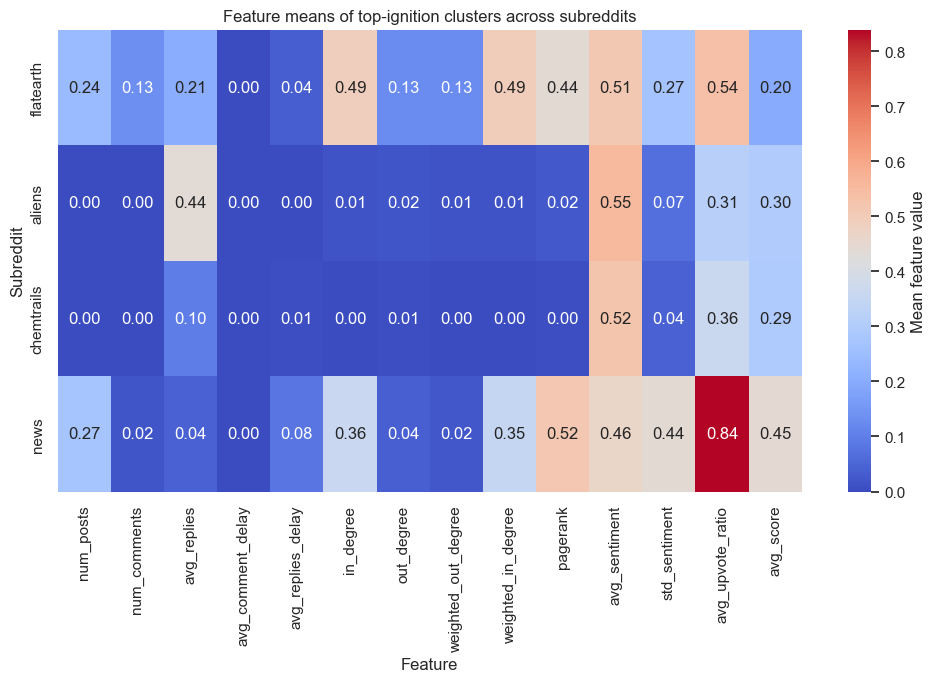

In [239]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(
    mean_df_norm,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={'label': 'Mean feature value'}
)
plt.title("Feature means of top-ignition clusters across subreddits")
plt.ylabel("Subreddit")
plt.xlabel("Feature")
plt.show()


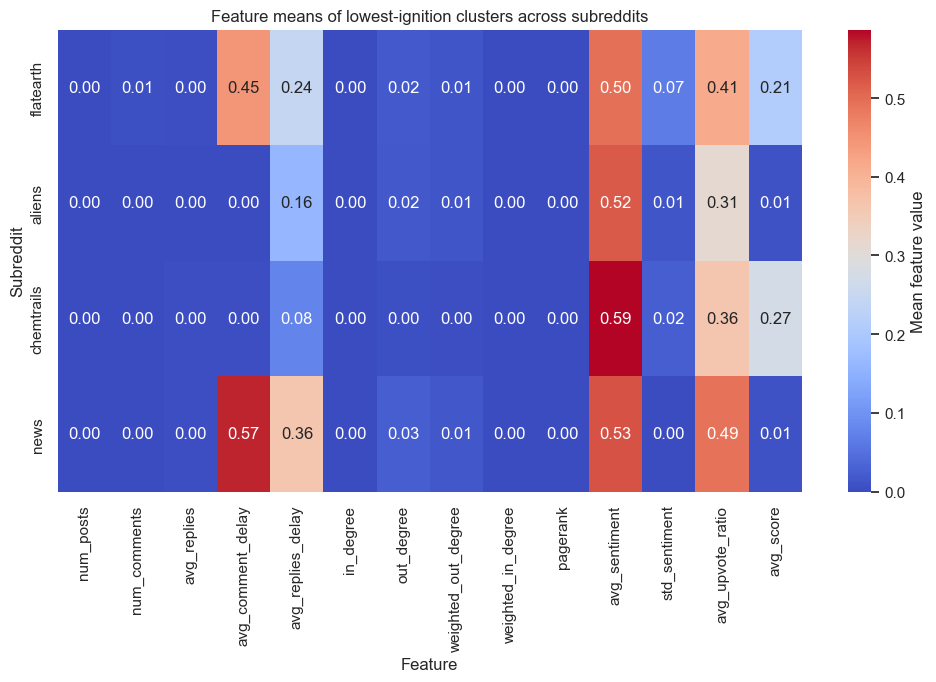

In [244]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(
    reverse_mean_df_norm,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={'label': 'Mean feature value'}
)
plt.title("Feature means of lowest-ignition clusters across subreddits")
plt.ylabel("Subreddit")
plt.xlabel("Feature")
plt.show()